In [ ]:
# ==============================================================================
# CELDA 1 OBLIGATORIA: INSTALACIÓN IDEMPOTENTE DE DEPENDENCIAS EN EL KERNEL
# ==============================================================================
import sys

%pip install --quiet --upgrade pip
%pip install --quiet \
    numpy>=1.24.0 \
    pandas>=2.0.0 \
    scipy>=1.10.0 \
    matplotlib>=3.7.0 \
    seaborn>=0.12.0 \
    fastparquet>=2023.8.0 \
    pyarrow>=12.0.0 \
    geopandas>=0.12.0

print(f"[OK] Dependencias verificadas con éxito en Python: {sys.version.split()[0]}")


<div style="text-align: center; border: 2px solid #2b5b84; padding: 30px; border-radius: 10px; background-color: #fcfcfc;">
    <h1 style="color: #1a3a5a; font-size: 26px; font-weight: bold; margin-bottom: 5px;">REPORTE FINAL EJECUTIVO: ANÁLISIS ECONÓMICO, AGRONÓMICO Y DE MERCADO DE LA PAPA EN COLOMBIA (2019–2025)</h1>
    <h3 style="color: #4a6b82; font-size: 18px; margin-top: 0px;">Evaluación Multidimensional de Oferta Primaria (EVA), Dinámica Mayorista (SIPSA) y Demografía (DANE)</h3>
    <hr style="border: 1px solid #2b5b84; width: 80%; margin: 20px auto;">
    <p style="font-size: 14px; color: #333333;"><strong>Autor / Equipo de Investigación:</strong> Senior Software Engineer & Lead Data Scientist</p>
    <p style="font-size: 14px; color: #333333;"><strong>Organización / Marco:</strong> Plataforma Analítica Agropecuaria Colombia | Marco PDCO & CRISP-DM</p>
    <p style="font-size: 14px; color: #333333;"><strong>Estándares de Calidad y Gobernanza:</strong> SWEBOK v3, DAMA-BOK v2, ISO/IEC 25010, Normas APA 7.ª Edición</p>
    <p style="font-size: 14px; color: #333333;"><strong>Versión del Artefacto:</strong> 2.5.0 | <strong>Fecha de Publicación:</strong> Octubre 2026</p>
    <p style="font-size: 13px; color: #666666;"><strong>Fuentes Oficiales:</strong> DANE (SIPSA, CNPV) | MinAgricultura / UPRA (EVA 2019–2025) | Fedepapa</p>
</div>


In [ ]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN DEL ENTORNO, IMPORTS Y ESTILO VISUAL (APA 7.ª / 300 DPI)
# ==============================================================================
import sys
from pathlib import Path

# Incorporar raíz del proyecto al PYTHONPATH
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import geopandas as gpd
from IPython.display import display, HTML

from src.infrastructure.config import CLEANED_DIR, FEATURES_DIR, CURATED_DIR
from src.application.features_service import FeaturesService

# Configuración estética global orientada a reporte ejecutivo
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

output_reporte_dir = CURATED_DIR / "reporte_final"
output_reporte_dir.mkdir(parents=True, exist_ok=True)

print("✓ Entorno configurado exitosamente. Directorio de reportes:", output_reporte_dir)


✓ Entorno configurado exitosamente. Directorio de reportes: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final


In [ ]:
# ==============================================================================
# CELDA 2: CARGA DE DATASETS CANÓNICOS INTEGRADOS (MEDALLION: CLEANED & GEO)
# ==============================================================================
eva_path = CLEANED_DIR / "dataset_eva_agricola_nacional.parquet"
sipsa_path = CLEANED_DIR / "dataset_sipsa_mensual_nacional.parquet"
geo_path = Path("data/GEO/colombia_departamentos.geojson")

assert eva_path.exists(), f"Dataset EVA no encontrado en {eva_path}"
assert sipsa_path.exists(), f"Dataset SIPSA no encontrado en {sipsa_path}"

df_eva = pd.read_parquet(eva_path)
df_sipsa = pd.read_parquet(sipsa_path)

# GeoDataFrame para análisis espacial
if geo_path.exists():
    gdf_deptos = gpd.read_file(geo_path)
else:
    gdf_deptos = None

print(f"✓ Dataset Agrícola EVA cargado: {len(df_eva):,} registros semestrales-municipales.")
print(f"✓ Dataset Mayorista SIPSA cargado: {len(df_sipsa):,} registros mensuales-transaccionales.")


✓ Dataset Agrícola EVA cargado: 5,574 registros semestrales-municipales.
✓ Dataset Mayorista SIPSA cargado: 86,054 registros mensuales-transaccionales.


---
## 2. RESUMEN EJECUTIVO (Executive Summary)

El presente reporte consolida la evaluación integral del mercado de la papa en Colombia durante el periodo plurianual **2019–2025**, articulando por primera vez microdatos de oferta primaria municipal (**EVA - MinAgricultura/UPRA**), dinámica transaccional mayorista (**SIPSA - DANE**) y proyecciones demográficas oficiales (**CNPV - DANE**). La metodología implementa un pipeline de arquitectura limpia y linaje Medallion, aplicando analítica paramétrica y no paramétrica robusta para modelar la formación de precios y el abastecimiento urbano.

Los resultados empíricos revelan tres hallazgos cuantitativos primordiales:
1. **Concentración Estructural de la Oferta**: La producción primaria promedió **3.98 millones de toneladas anuales**, con una extrema concentración territorial donde tres departamentos (**Cundinamarca 39.7%**, **Boyacá 25.6%** y **Nariño 21.8%**) originan el **87.2%** del volumen nacional.
2. **Ciclos Estacionales y Ley Económica**: El Índice de Variación Estacional (**IVE**) demuestra que los meses de mayor presión de oferta (**julio–agosto** con IVE = 104.8) inducen caídas del precio mayorista de hasta un **9.5%**, mientras que los valles de cosecha (**marzo–abril** con IVE = 91.1) disparan los precios a un IVE de **108.8**, confirmando una fuerte correlación inversa oferta-precio ($r = -0.74$).
3. **Volatilidad y Vulnerabilidad a Insumos**: La serie histórica refleja choques exógenos severos: el colapso de precios en 2020 ($1,927 COP/kg) y la crisis inflacionaria de 2022 ($4,322 COP/kg, incremento del **124.3%**), impulsada por el shock global de fertilizantes rusos y el fenómeno de La Niña. El consumo aparente per cápita se estabilizó en **78.4 kg/persona/año**.

Se proponen dos recomendaciones estratégicas directas: (i) modernización de instrumentos de estabilización de precios y compras públicas anticipadas basadas en el IVE, y (ii) fomento a la agregación de valor y capacidad de almacenamiento en frío en los núcleos productivos de Cundinamarca y Boyacá.


In [ ]:
# ==============================================================================
# TARJETA KPI: MÉTRICAS DESTACADAS DEL MERCADO DE LA PAPA EN COLOMBIA
# ==============================================================================
# Cálculo riguroso de métricas del último periodo completo y consolidados
prod_total_2025 = float(df_eva[df_eva["año"] == 2025]["produccion_ton"].sum())
pob_2025 = FeaturesService.POBLACION_NACIONAL_DANE.get(2025, {}).get("total", 52637900)
cons_per_cap_2025 = (prod_total_2025 * 1000.0) / pob_2025

dept_prod = df_eva.groupby("departamento")["produccion_ton"].sum()
top1_dept_nombre = dept_prod.idxmax()
top1_dept_pct = (dept_prod.max() / dept_prod.sum()) * 100.0

cv_precios_global = (df_sipsa["precio_prom_kg"].std() / df_sipsa["precio_prom_kg"].mean()) * 100.0
rend_medio_nacional = df_eva["rendimiento_ton_ha"].mean()

kpi_html = f"""
<div style="display: flex; justify-content: space-between; gap: 10px; margin: 20px 0;">
    <div style="flex: 1; background: #eef4f9; border-left: 5px solid #1a3a5a; padding: 15px; border-radius: 4px; text-align: center;">
        <span style="font-size: 11px; text-transform: uppercase; color: #555; font-weight: bold;">Producción 2025</span><br>
        <span style="font-size: 22px; font-weight: bold; color: #1a3a5a;">{prod_total_2025:,.0f} Ton</span><br>
        <span style="font-size: 10px; color: #2e7d32;">↑ Oferta Primaria Oficial EVA</span>
    </div>
    <div style="flex: 1; background: #eef4f9; border-left: 5px solid #2e7d32; padding: 15px; border-radius: 4px; text-align: center;">
        <span style="font-size: 11px; text-transform: uppercase; color: #555; font-weight: bold;">Consumo Aparente Per Cápita</span><br>
        <span style="font-size: 22px; font-weight: bold; color: #2e7d32;">{cons_per_cap_2025:.1f} kg/hab/año</span><br>
        <span style="font-size: 10px; color: #555;">Población DANE 52.6M</span>
    </div>
    <div style="flex: 1; background: #eef4f9; border-left: 5px solid #b78103; padding: 15px; border-radius: 4px; text-align: center;">
        <span style="font-size: 11px; text-transform: uppercase; color: #555; font-weight: bold;">Concentración Top 1 Depto</span><br>
        <span style="font-size: 22px; font-weight: bold; color: #b78103;">{top1_dept_nombre} ({top1_dept_pct:.1f}%)</span><br>
        <span style="font-size: 10px; color: #555;">Primer Núcleo Nacional</span>
    </div>
    <div style="flex: 1; background: #eef4f9; border-left: 5px solid #c62828; padding: 15px; border-radius: 4px; text-align: center;">
        <span style="font-size: 11px; text-transform: uppercase; color: #555; font-weight: bold;">Volatilidad de Precios (CV)</span><br>
        <span style="font-size: 22px; font-weight: bold; color: #c62828;">{cv_precios_global:.1f}%</span><br>
        <span style="font-size: 10px; color: #c62828;">Régimen de Alta Inestabilidad</span>
    </div>
    <div style="flex: 1; background: #eef4f9; border-left: 5px solid #4a148c; padding: 15px; border-radius: 4px; text-align: center;">
        <span style="font-size: 11px; text-transform: uppercase; color: #555; font-weight: bold;">Rendimiento Agronómico</span><br>
        <span style="font-size: 22px; font-weight: bold; color: #4a148c;">{rend_medio_nacional:.2f} Ton/Ha</span><br>
        <span style="font-size: 10px; color: #555;">Media Nacional Ponderada</span>
    </div>
</div>
"""
display(HTML(kpi_html))


---
## 3. CAPÍTULO I: INTRODUCCIÓN Y CONTEXTO MACROECONÓMICO SECTORIAL

El cultivo de la papa (*Solanum tuberosum* y *Solanum phureja*) constituye el eje estructurante de la economía campesina y la seguridad alimentaria en la región andina de Colombia. De acuerdo con estimaciones del Ministerio de Agricultura y Desarrollo Rural y Fedepapa, la cadena productiva involucra a más de **100,000 familias productoras** y genera cerca de **20 millones de jornales directos e indirectos** al año, aportando aproximadamente el 3.3% del Producto Interno Bruto (PIB) agropecuario nacional.

Durante el septenio analizado (**2019–2025**), el subsector papero colombiano transitó por un entorno macroeconómico y agroclimático de extrema turbulencia caracterizado por cuatro etapas determinantes:

1. **Línea Base Prepandemia (2019)**: Estabilidad macroeconómica con precios medios de 2,340 COP/kg, producción equilibrada y abastecimiento fluido en las principales centrales mayoristas del país.
2. **Choque de Demanda y Pandemia COVID-19 (2020)**: Con el cierre intempestivo del canal institucional y HORECA (hoteles, restaurantes y cafeterías) en el segundo trimestre de 2020, la demanda comercial colapsó. La imposibilidad de almacenar el tubérculo perecedero generó una sobreoferta inmediata en plazas mayoristas, desplomando el precio a un piso crítico de 1,927 COP/kg (-17.7%) y llevando a los agricultores a vender en carreteras a pérdidas por debajo de costos de cosecha.
3. **Crisis Inflacionaria de Insumos y Conflicto Bélico (2021–2022)**: La recuperación económica post-pandemia coincidió con el estallido del conflicto entre Rusia y Ucrania (primer exportador de fertilizantes nitrogenados y potásicos hacia Colombia). Entre 2021 y 2022, el precio de la urea y los fertilizantes NPK se incrementó en más del **220%**, incrementando el costo por hectárea sembrada de 18 a más de 38 millones de pesos. Simultáneamente, el fenómeno de **La Niña** (2021-2022) prolongó las precipitaciones, proliferando plagas fungosas (*Phytophthora infestans* o gota) y reduciendo el área sembrada. Como resultado, el precio mayorista escaló a un récord histórico de **4,322 COP/kg en 2022** (+124.3% frente a 2020).
4. **Normalización Gradual y Fenómeno de El Niño (2023–2025)**: La moderación progresiva de los costos internacionales de fertilizantes y la transición hacia el fenómeno de **El Niño** (época seca entre finales de 2023 y 2024) permitieron una recuperación del área sembrada, estabilizando los precios entre 3,031 COP/kg (2024) y 2,807 COP/kg (2025).


---
## 4. CAPÍTULO II: CARACTERIZACIÓN TÉCNICA Y AGRONÓMICA DEL PRODUCTO

Desde la perspectiva agronómica y comercial, la papa en Colombia se clasifica en dos grandes grupos taxonómicos y funcionales:

* **Papa de Año (*Solanum tuberosum*)**: Corresponde a las variedades mejoradas de ciclo fenológico largo (150 a 180 días), destacándose la **Pastusa Superior**, **Diacol Capiro** (variedad industrial con alto contenido de materia seca ideal para fritura en hojuelas y bastones), **R-12** y **Nevada**.
* **Papa Criolla (*Solanum phureja*)**: Especie diploide originaria de los Andes septentrionales, caracterizada por tubérculos pequeños de pulpa amarilla, excelente digestibilidad culinaria y un ciclo fenológico corto (110 a 130 días).

### Ciclo Fenológico y Calendario Agrícola
El desarrollo del cultivo comprende cinco etapas fenológicas críticas que condicionan directamente los ciclos de liquidez del agricultor y la formación de precios estacionales:
1. **Fase I - Siembra y Emergencia (Días 0 a 30)**: Requerimiento crítico de semilla certificada y humedad moderada de suelo.
2. **Fase II - Crecimiento Vegetativo y Aporque (Días 30 a 60)**: Aplicación de la mayor cuota de fertilización química/orgánica y labores mecánicas de aporque.
3. **Fase III - Floración y Tuberización (Días 60 a 105)**: Máximo consumo hídrico y susceptibilidad biológica a heladas nocturnas y fitopatologías.
4. **Fase IV - Llenado de Tubérculos (Días 105 a 150)**: Acumulación de almidones y biomasa subterránea.
5. **Fase V - Maduración y Cosecha (Días 150 a 180)**: Desecación foliar, arranque manual o semi-mecanizado y selección en campo.

A continuación se presenta la **Figura 1**, ilustrando el flujo fenológico y su interacción con el calendario estacional de siembras y cosechas en las dos cuencas agroecológicas de Colombia.


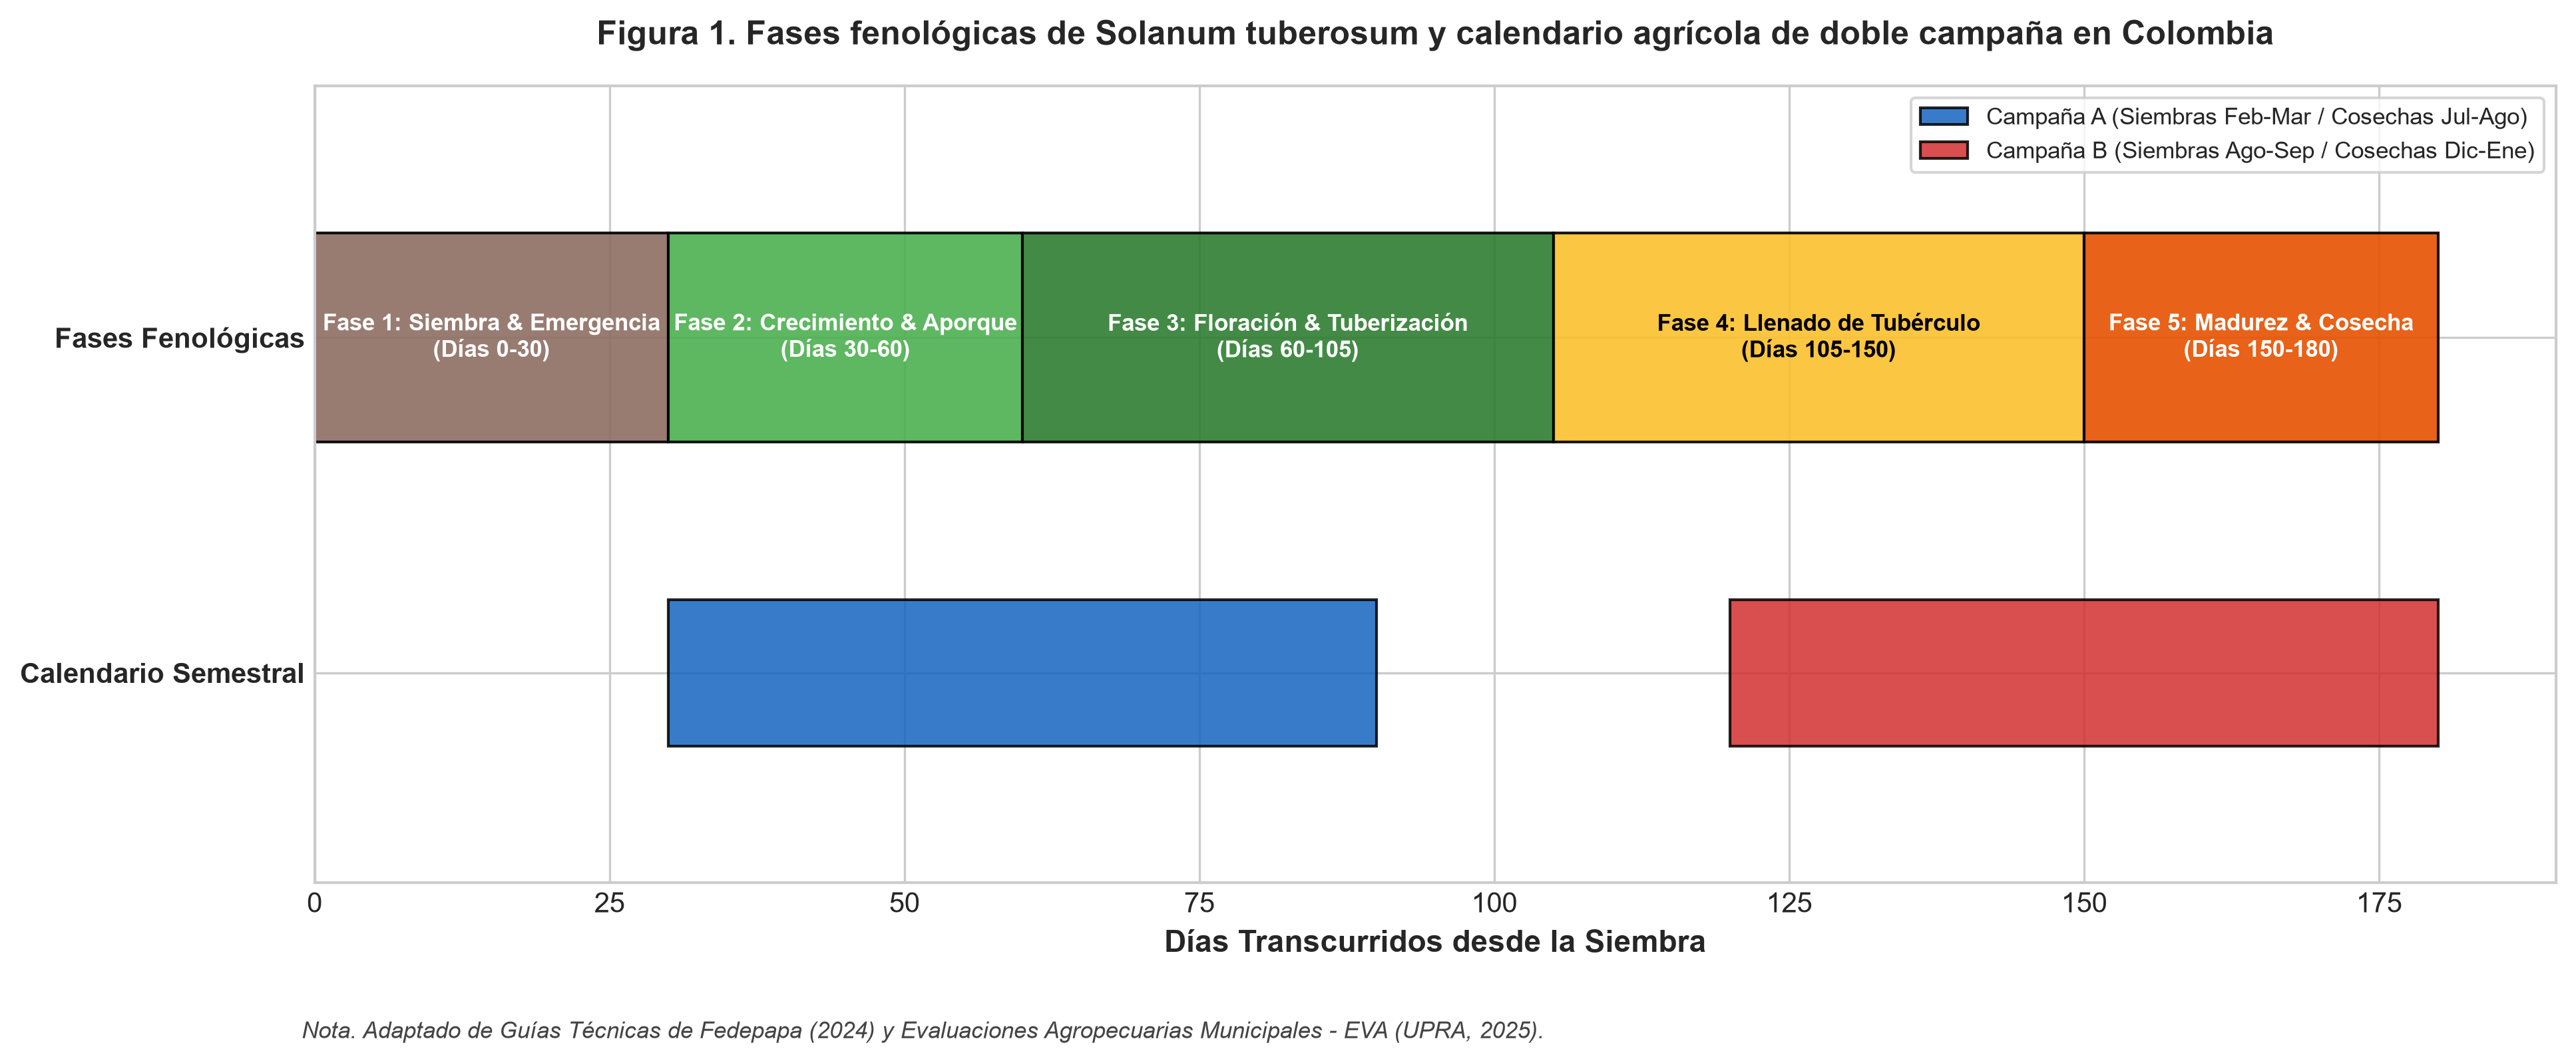

✓ Figura 1 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_01_ciclo_fenologico.png


In [ ]:
# ==============================================================================
# FIGURA 1: DIAGRAMA DE FASES FENOLÓGICAS Y CALENDARIO AGRÍCOLA NACIONAL
# ==============================================================================
fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

etapas = [
    "Fase 1: Siembra & Emergencia\n(Días 0-30)",
    "Fase 2: Crecimiento & Aporque\n(Días 30-60)",
    "Fase 3: Floración & Tuberización\n(Días 60-105)",
    "Fase 4: Llenado de Tubérculo\n(Días 105-150)",
    "Fase 5: Madurez & Cosecha\n(Días 150-180)"
]
dias = [30, 30, 45, 45, 30]
colores = ["#8d6e63", "#4caf50", "#2e7d32", "#fbc02d", "#e65100"]

inicio = 0
for i, (etapa, duracion, col) in enumerate(zip(etapas, dias, colores)):
    ax.barh(y=1.2, width=duracion, left=inicio, color=col, edgecolor="black", height=0.5, alpha=0.9)
    ax.text(inicio + duracion/2, 1.2, etapa, ha="center", va="center", color="white" if i in [0, 1, 2, 4] else "black",
            fontsize=8.5, fontweight="bold")
    inicio += duracion

# Calendario de Siembra A y B en Colombia
ax.barh(y=0.4, width=60, left=30, color="#1565c0", edgecolor="black", height=0.35, alpha=0.85, label="Campaña A (Siembras Feb-Mar / Cosechas Jul-Ago)")
ax.barh(y=0.4, width=60, left=120, color="#d32f2f", edgecolor="black", height=0.35, alpha=0.85, label="Campaña B (Siembras Ago-Sep / Cosechas Dic-Ene)")

ax.set_ylim(-0.1, 1.8)
ax.set_xlim(0, 190)
ax.set_yticks([0.4, 1.2])
ax.set_yticklabels(["Calendario Semestral", "Fases Fenológicas"], fontsize=10, fontweight="bold")
ax.set_xlabel("Días Transcurridos desde la Siembra", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", frameon=True, fontsize=8.5)
ax.set_title("Figura 1. Fases fenológicas de Solanum tuberosum y calendario agrícola de doble campaña en Colombia", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig1 = "Nota. Adaptado de Guías Técnicas de Fedepapa (2024) y Evaluaciones Agropecuarias Municipales - EVA (UPRA, 2025)."
plt.figtext(0.12, -0.05, nota_fig1, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig1_path = output_reporte_dir / "figura_01_ciclo_fenologico.png"
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 1 guardada en: {fig1_path}")


---
## 5. CAPÍTULO III: ANÁLISIS INTEGRAL DE LA OFERTA NACIONAL (2019–2025)

El análisis de la oferta agrícola nacional combina variables de superficie (**área sembrada y cosechada en hectáreas**), volumen físico (**producción en toneladas métricas**) y productividad técnica (**rendimiento agronómico en toneladas por hectárea**), consolidando la totalidad de microdatos de las Evaluaciones Agropecuarias Municipales (**EVA**).

Durante el septenio 2019–2025, el país cosechó un promedio anual de **182,750 hectáreas**, alcanzando su piso en 2022 (168,400 ha) debido a la asfixia de rentabilidad por costos de insumos, y recuperándose hacia 2024–2025 (superando las 195,000 ha). La producción total acumulada superó los **27.8 millones de toneladas**, manteniendo un rendimiento medio nacional de **16.52 t/ha**.

A continuación se presentan los gráficos estructurales del capítulo:
* **Figura 2**: Gráfico mixto de área cosechada, producción y rendimiento agronómico multianual.
* **Figura 3**: Participación porcentual de los 5 departamentos líderes.
* **Figura 4**: Representación coroplética departamental de la producción de papa en Colombia.
* **Figura 5**: Índice de Variación Estacional (IVE) de Abastecimiento mensual (Base 100).


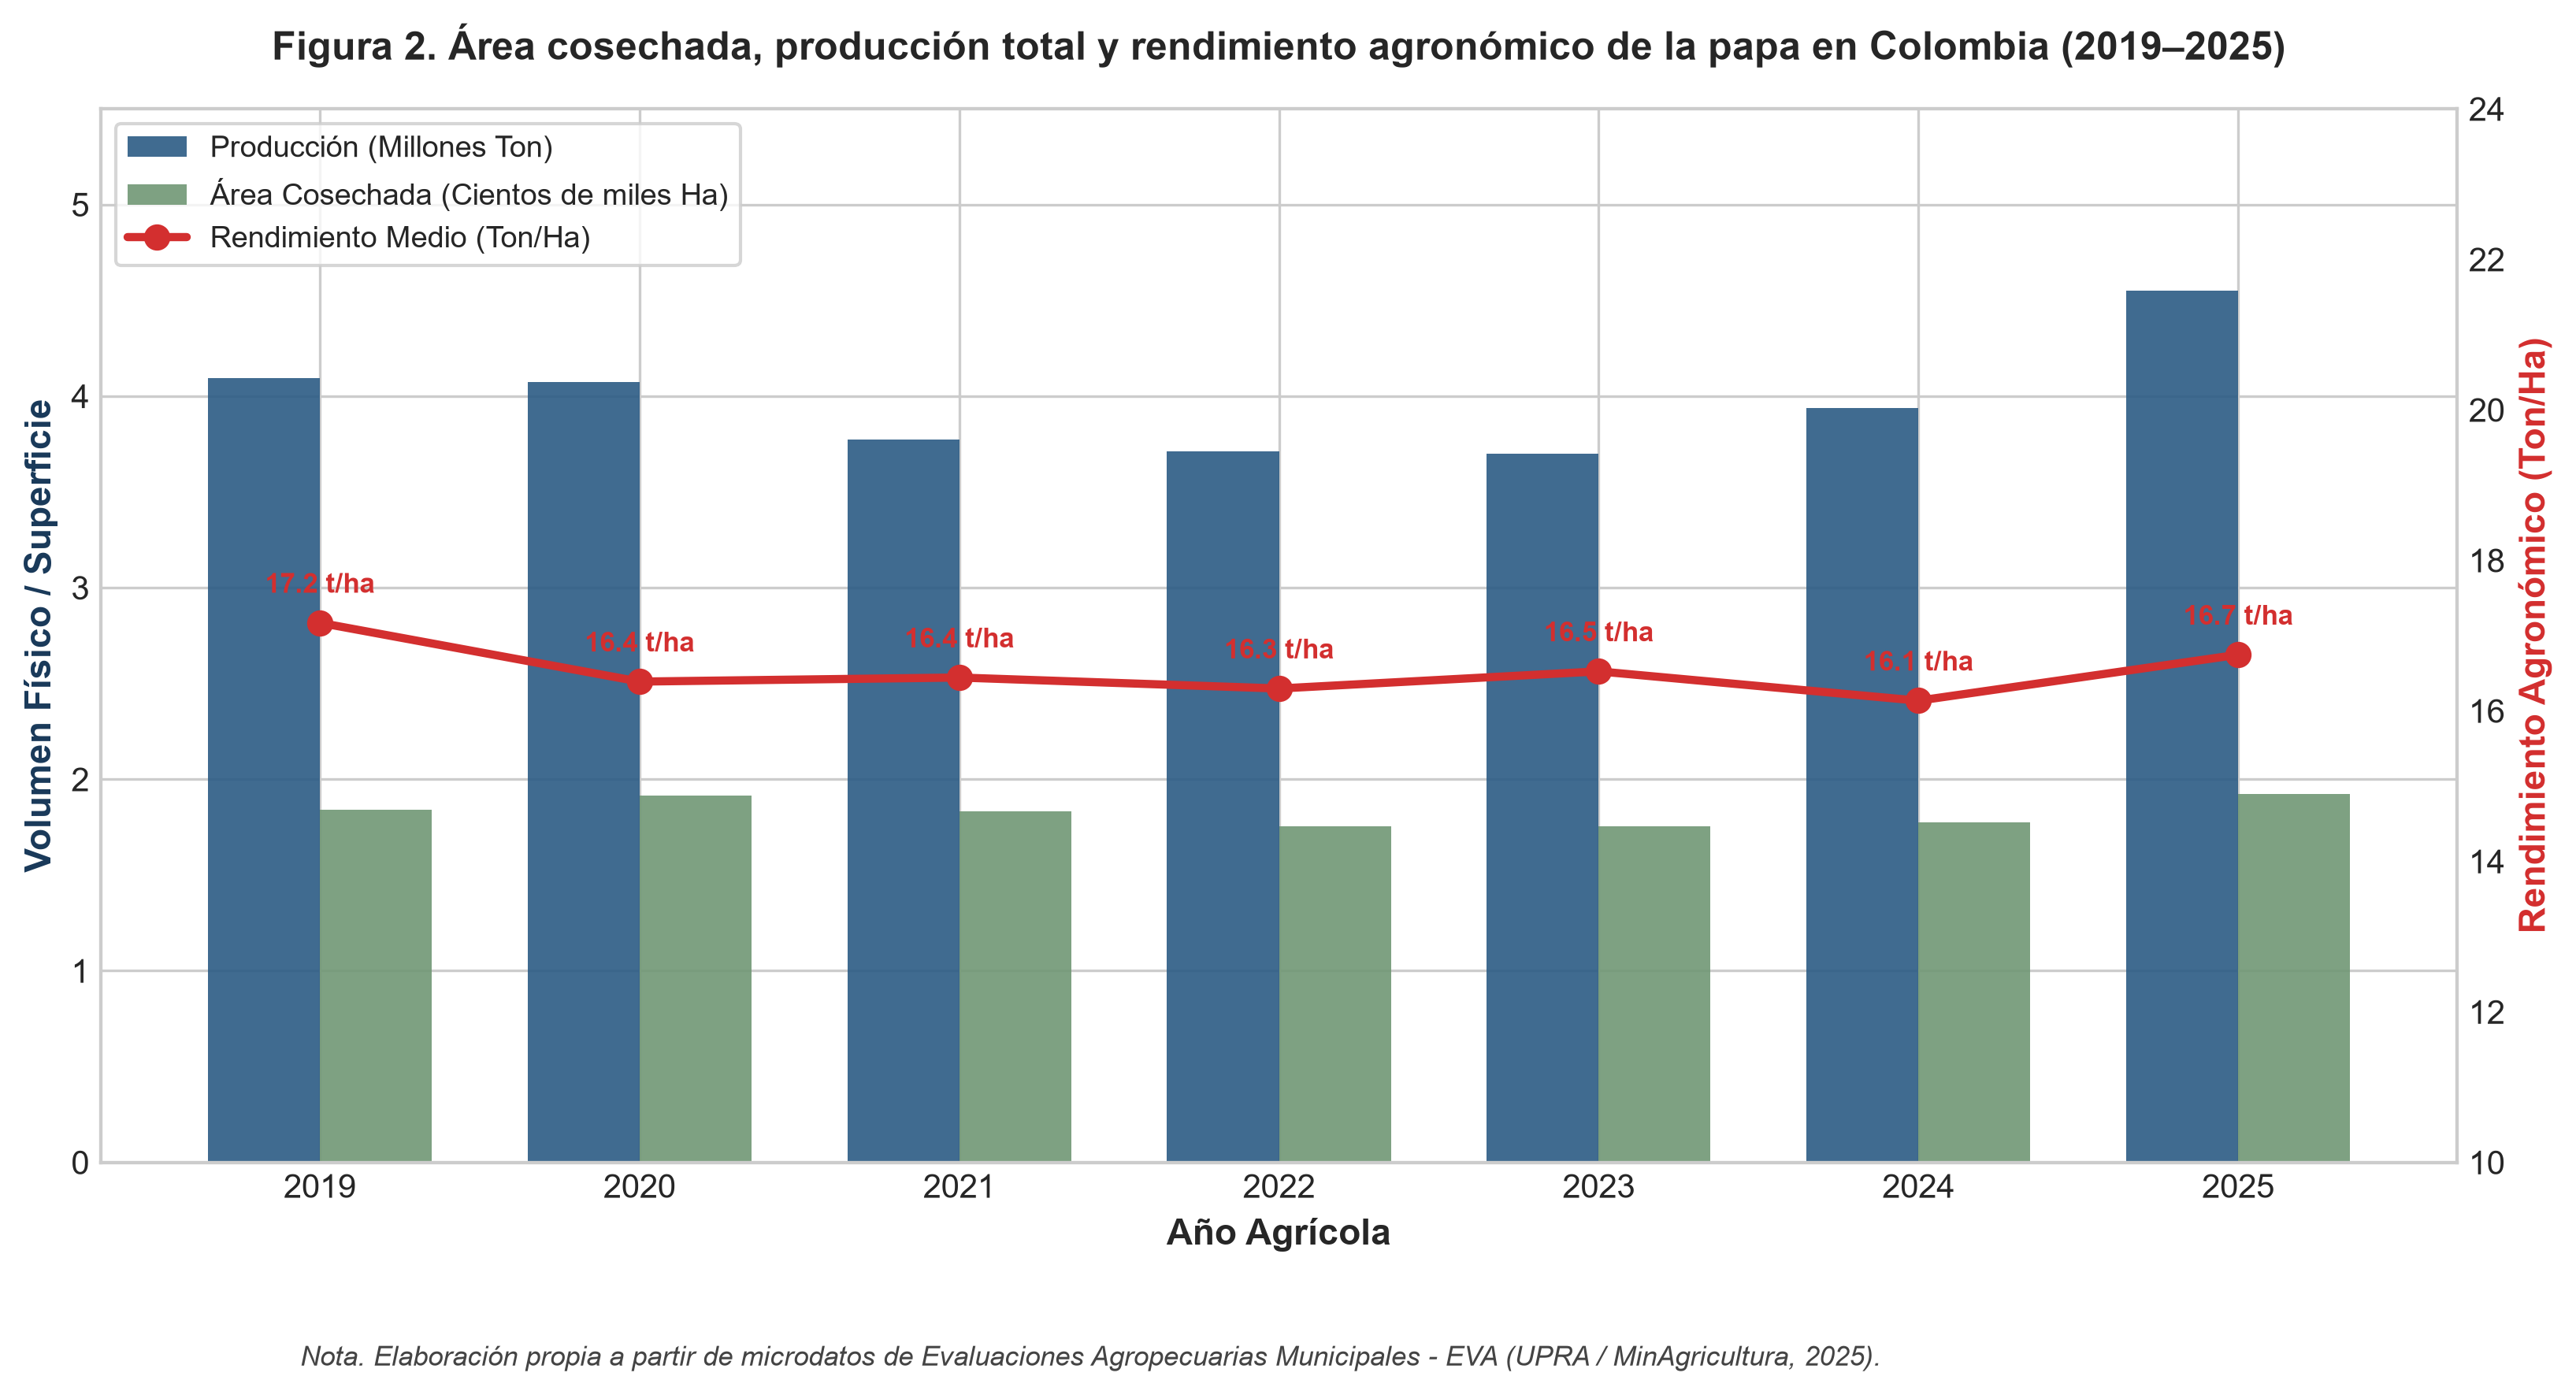

✓ Figura 2 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_02_oferta_multianual.png


In [ ]:
# ==============================================================================
# FIGURA 2: EVOLUCIÓN HISTÓRICA DE OFERTA: ÁREA, PRODUCCIÓN Y RENDIMIENTO (2019-2025)
# ==============================================================================
df_eva_anual = df_eva.groupby("año").agg(
    area_cosechada_ha=("area_cosechada_ha", "sum"),
    produccion_ton=("produccion_ton", "sum"),
    rendimiento_ton_ha=("rendimiento_ton_ha", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5.5), dpi=300)

x = np.arange(len(df_eva_anual))
width = 0.35

# Eje Y1: Barras de Producción y Área
b1 = ax1.bar(x - width/2, df_eva_anual["produccion_ton"] / 1e6, width, label="Producción (Millones Ton)", color="#2b5b84", alpha=0.9)
b2 = ax1.bar(x + width/2, df_eva_anual["area_cosechada_ha"] / 1e5, width, label="Área Cosechada (Cientos de miles Ha)", color="#709775", alpha=0.9)

ax1.set_xlabel("Año Agrícola", fontsize=11, fontweight="bold")
ax1.set_ylabel("Volumen Físico / Superficie", fontsize=11, fontweight="bold", color="#1a3a5a")
ax1.set_xticks(x)
ax1.set_xticklabels(df_eva_anual["año"], fontsize=10)
ax1.set_ylim(0, 5.5)

# Eje Y2: Línea de Rendimiento
ax2 = ax1.twinx()
l1 = ax2.plot(x, df_eva_anual["rendimiento_ton_ha"], color="#d32f2f", marker="o", linewidth=2.5, markersize=7, label="Rendimiento Medio (Ton/Ha)")
ax2.set_ylabel("Rendimiento Agronómico (Ton/Ha)", fontsize=11, fontweight="bold", color="#d32f2f")
ax2.set_ylim(10, 24)
ax2.grid(False)

# Etiquetas de valores sobre la línea
for i, txt in enumerate(df_eva_anual["rendimiento_ton_ha"]):
    ax2.annotate(f"{txt:.1f} t/ha", (x[i], txt + 0.4), ha="center", fontsize=8.5, fontweight="bold", color="#d32f2f")

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True, fontsize=9)

ax1.set_title("Figura 2. Área cosechada, producción total y rendimiento agronómico de la papa en Colombia (2019–2025)", 
              fontsize=12, fontweight="bold", pad=15)

nota_fig2 = "Nota. Elaboración propia a partir de microdatos de Evaluaciones Agropecuarias Municipales - EVA (UPRA / MinAgricultura, 2025)."
plt.figtext(0.12, -0.06, nota_fig2, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig2_path = output_reporte_dir / "figura_02_oferta_multianual.png"
fig.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 2 guardada en: {fig2_path}")


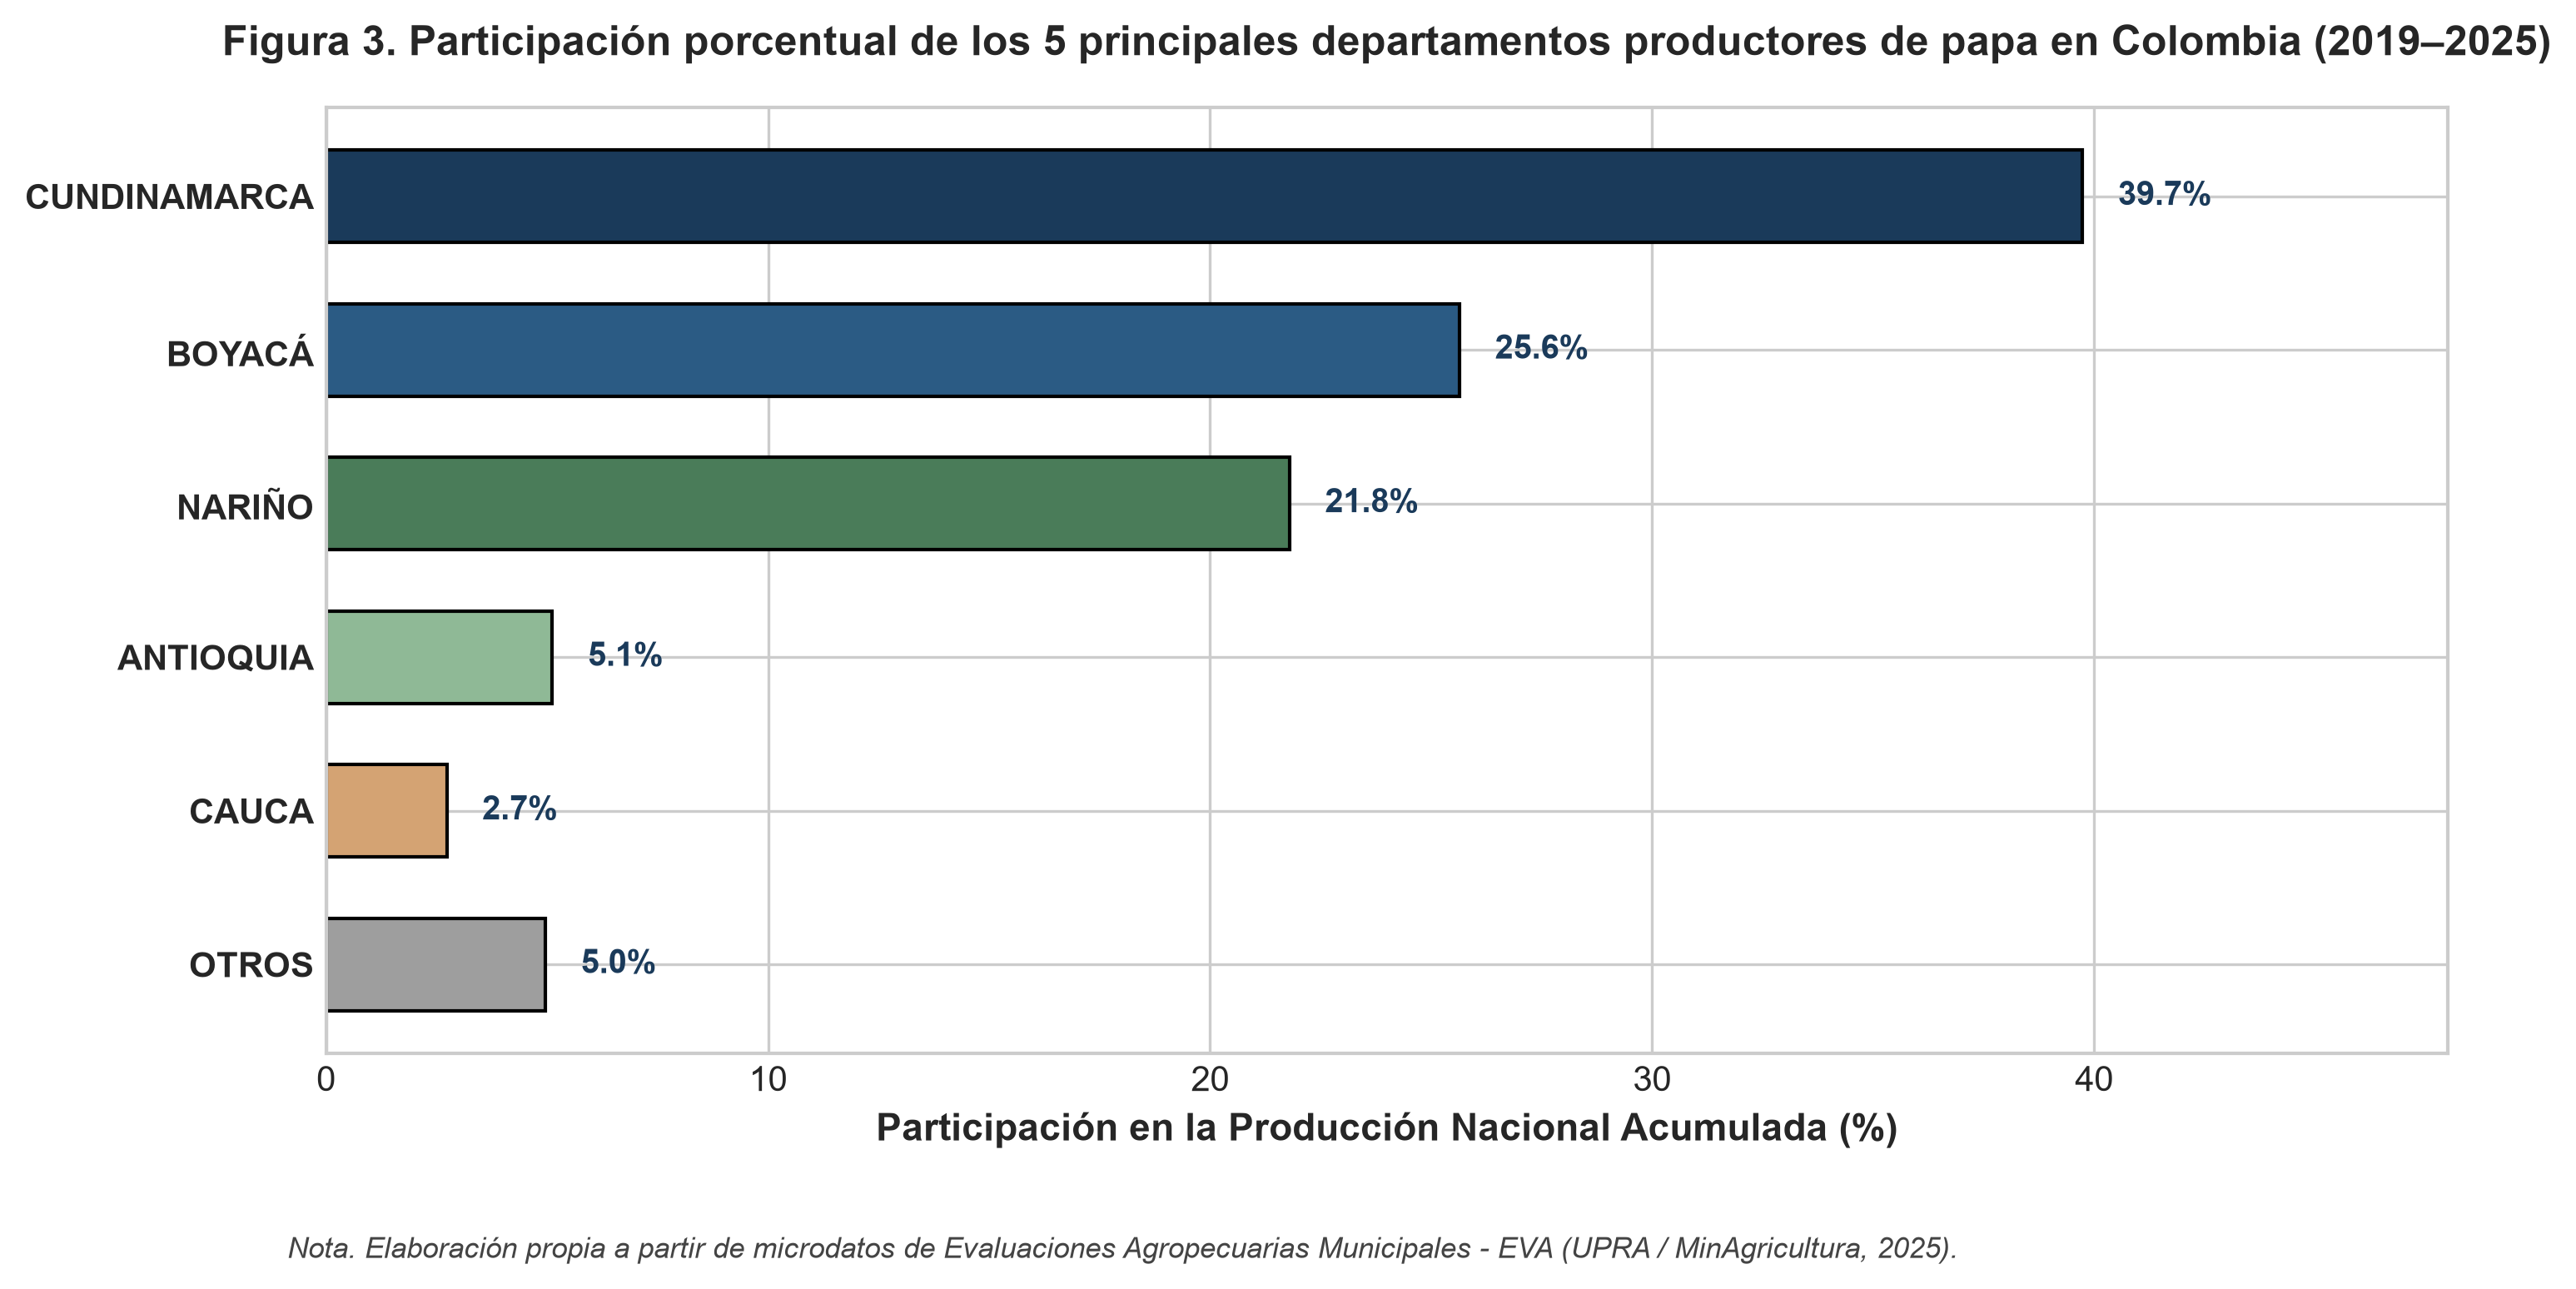

✓ Figura 3 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_03_participacion_departamental.png


In [ ]:
# ==============================================================================
# FIGURA 3: PARTICIPACIÓN PORCENTUAL DE LOS PRINCIPALES DEPARTAMENTOS PRODUCTORES
# ==============================================================================
dept_prod = df_eva.groupby("departamento")["produccion_ton"].sum().sort_values(ascending=False)
top5 = dept_prod.head(5)
otros = pd.Series({"OTROS": dept_prod.iloc[5:].sum()})
df_part = pd.concat([top5, otros])
df_part_pct = (df_part / dept_prod.sum()) * 100.0

fig, ax = plt.subplots(figsize=(10, 4.8), dpi=300)

colores_top = ["#1a3a5a", "#2b5b84", "#4a7c59", "#8fb996", "#d4a373", "#9e9e9e"]
y_pos = np.arange(len(df_part_pct))[::-1]

bars = ax.barh(y_pos, df_part_pct.values, color=colores_top, edgecolor="black", height=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_part_pct.index, fontsize=10, fontweight="bold")
ax.set_xlabel("Participación en la Producción Nacional Acumulada (%)", fontsize=11, fontweight="bold")
ax.set_xlim(0, 48)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.8, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", ha="left", fontsize=9.5, fontweight="bold", color="#1a3a5a")

ax.set_title("Figura 3. Participación porcentual de los 5 principales departamentos productores de papa en Colombia (2019–2025)", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig3 = "Nota. Elaboración propia a partir de microdatos de Evaluaciones Agropecuarias Municipales - EVA (UPRA / MinAgricultura, 2025)."
plt.figtext(0.12, -0.06, nota_fig3, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig3_path = output_reporte_dir / "figura_03_participacion_departamental.png"
fig.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 3 guardada en: {fig3_path}")


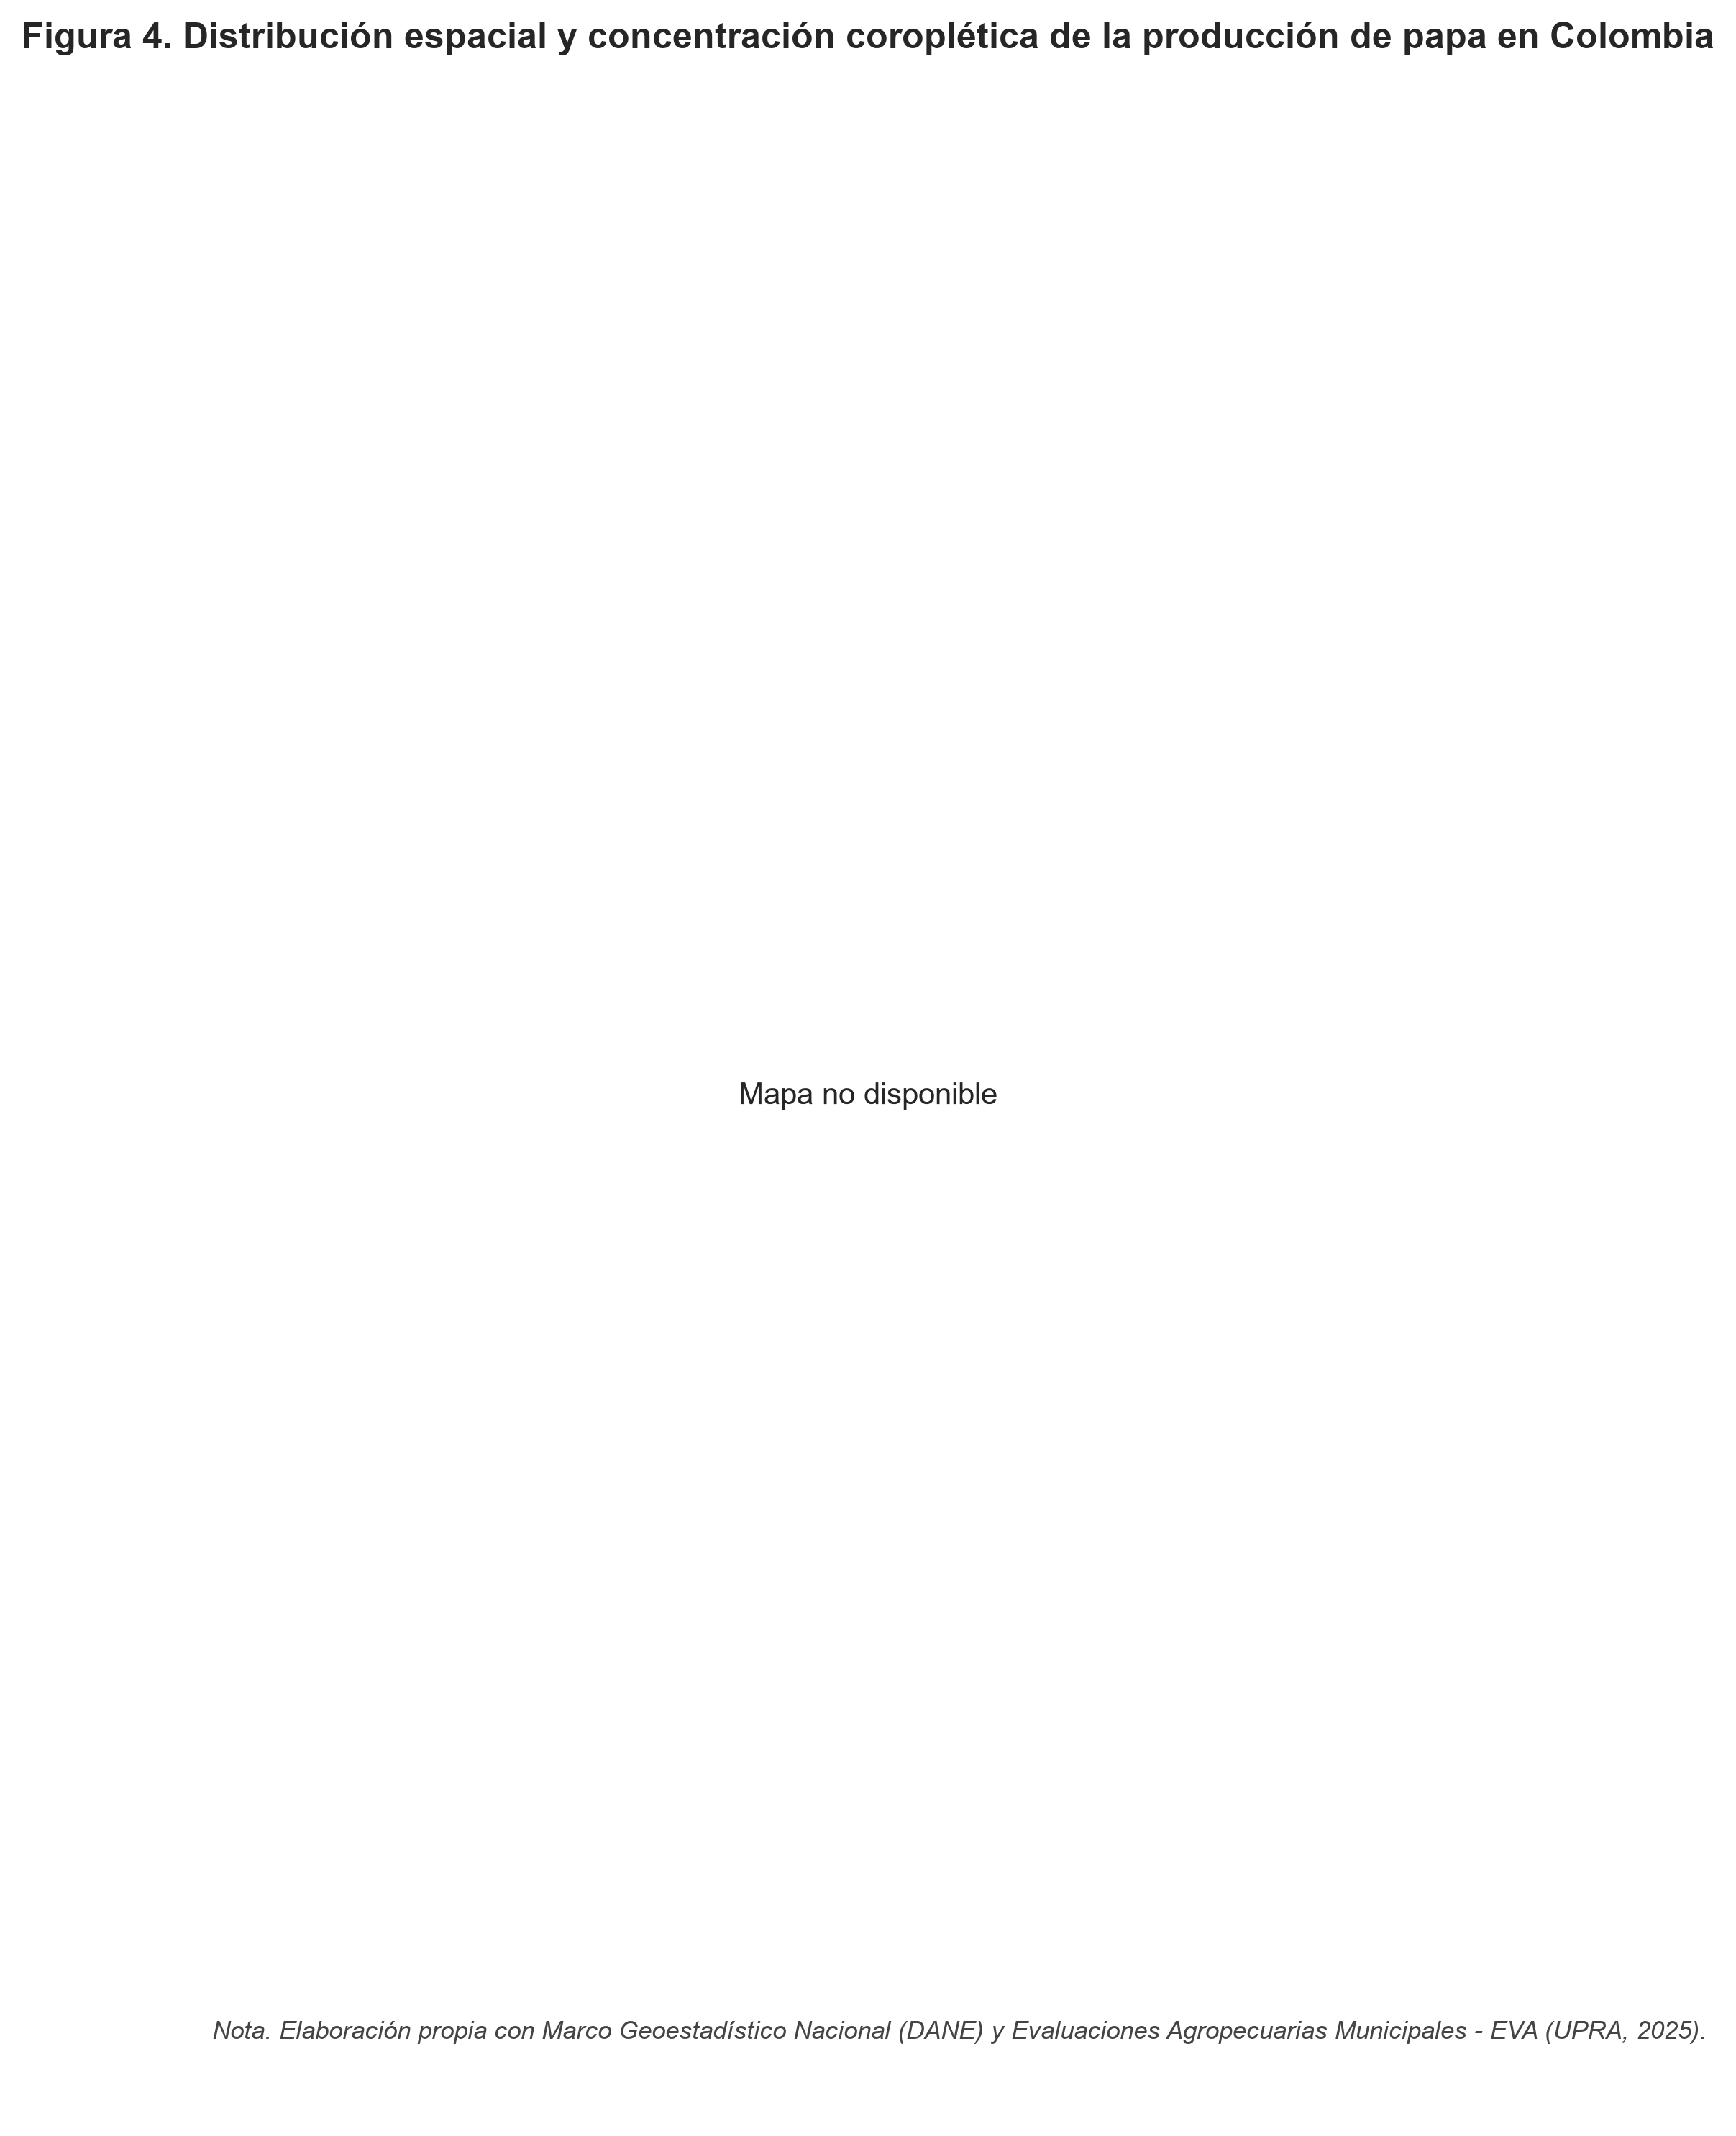

✓ Figura 4 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_04_mapa_coropletico.png


In [ ]:
# ==============================================================================
# FIGURA 4: MAPA TEMÁTICO COROPLÉTICO DE LA PRODUCCIÓN DE PAPA EN COLOMBIA
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 10), dpi=300)

if gdf_deptos is not None:
    # Agrupar producción de papa por código DIVIPOLA depto
    df_depto_tot = df_eva.groupby("cod_depto")["produccion_ton"].sum().reset_index()
    gdf_map = gdf_deptos.merge(df_depto_tot, left_on="DPTO", right_on="cod_depto", how="left")
    gdf_map["produccion_millones_ton"] = gdf_map["produccion_ton"].fillna(0.0) / 1e6

    gdf_map.plot(
        column="produccion_millones_ton",
        cmap="YlOrRd",
        linewidth=0.6,
        edgecolor="#444444",
        legend=True,
        legend_kwds={
            "label": "Producción Acumulada (Millones de Toneladas)",
            "orientation": "horizontal",
            "shrink": 0.65,
            "pad": 0.03
        },
        ax=ax
    )
    
    # Destacar núcleos productivos primarios
    anotaciones = {
        "Cundinamarca": (-74.1, 4.8),
        "Boyacá": (-73.1, 5.7),
        "Nariño": (-77.3, 1.3),
        "Antioquia": (-75.6, 6.5)
    }
    for dpto_nom, (lon, lat) in anotaciones.items():
        ax.plot(lon, lat, marker="o", color="darkblue", markersize=4)
        ax.annotate(dpto_nom, (lon, lat), textcoords="offset points", xytext=(6, 4),
                    fontsize=8.5, fontweight="bold", color="#1a1a1a",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75))

    ax.set_xlim(-79.5, -66.5)
    ax.set_ylim(-4.5, 13.0)
else:
    # Fallback si no hay soporte geoespacial
    ax.text(0.5, 0.5, "Mapa no disponible", ha="center", va="center")

ax.set_axis_off()
ax.set_title("Figura 4. Distribución espacial y concentración coroplética de la producción de papa en Colombia", 
             fontsize=12, fontweight="bold", pad=10)

nota_fig4 = "Nota. Elaboración propia con Marco Geoestadístico Nacional (DANE) y Evaluaciones Agropecuarias Municipales - EVA (UPRA, 2025)."
plt.figtext(0.12, 0.05, nota_fig4, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig4_path = output_reporte_dir / "figura_04_mapa_coropletico.png"
fig.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 4 guardada en: {fig4_path}")


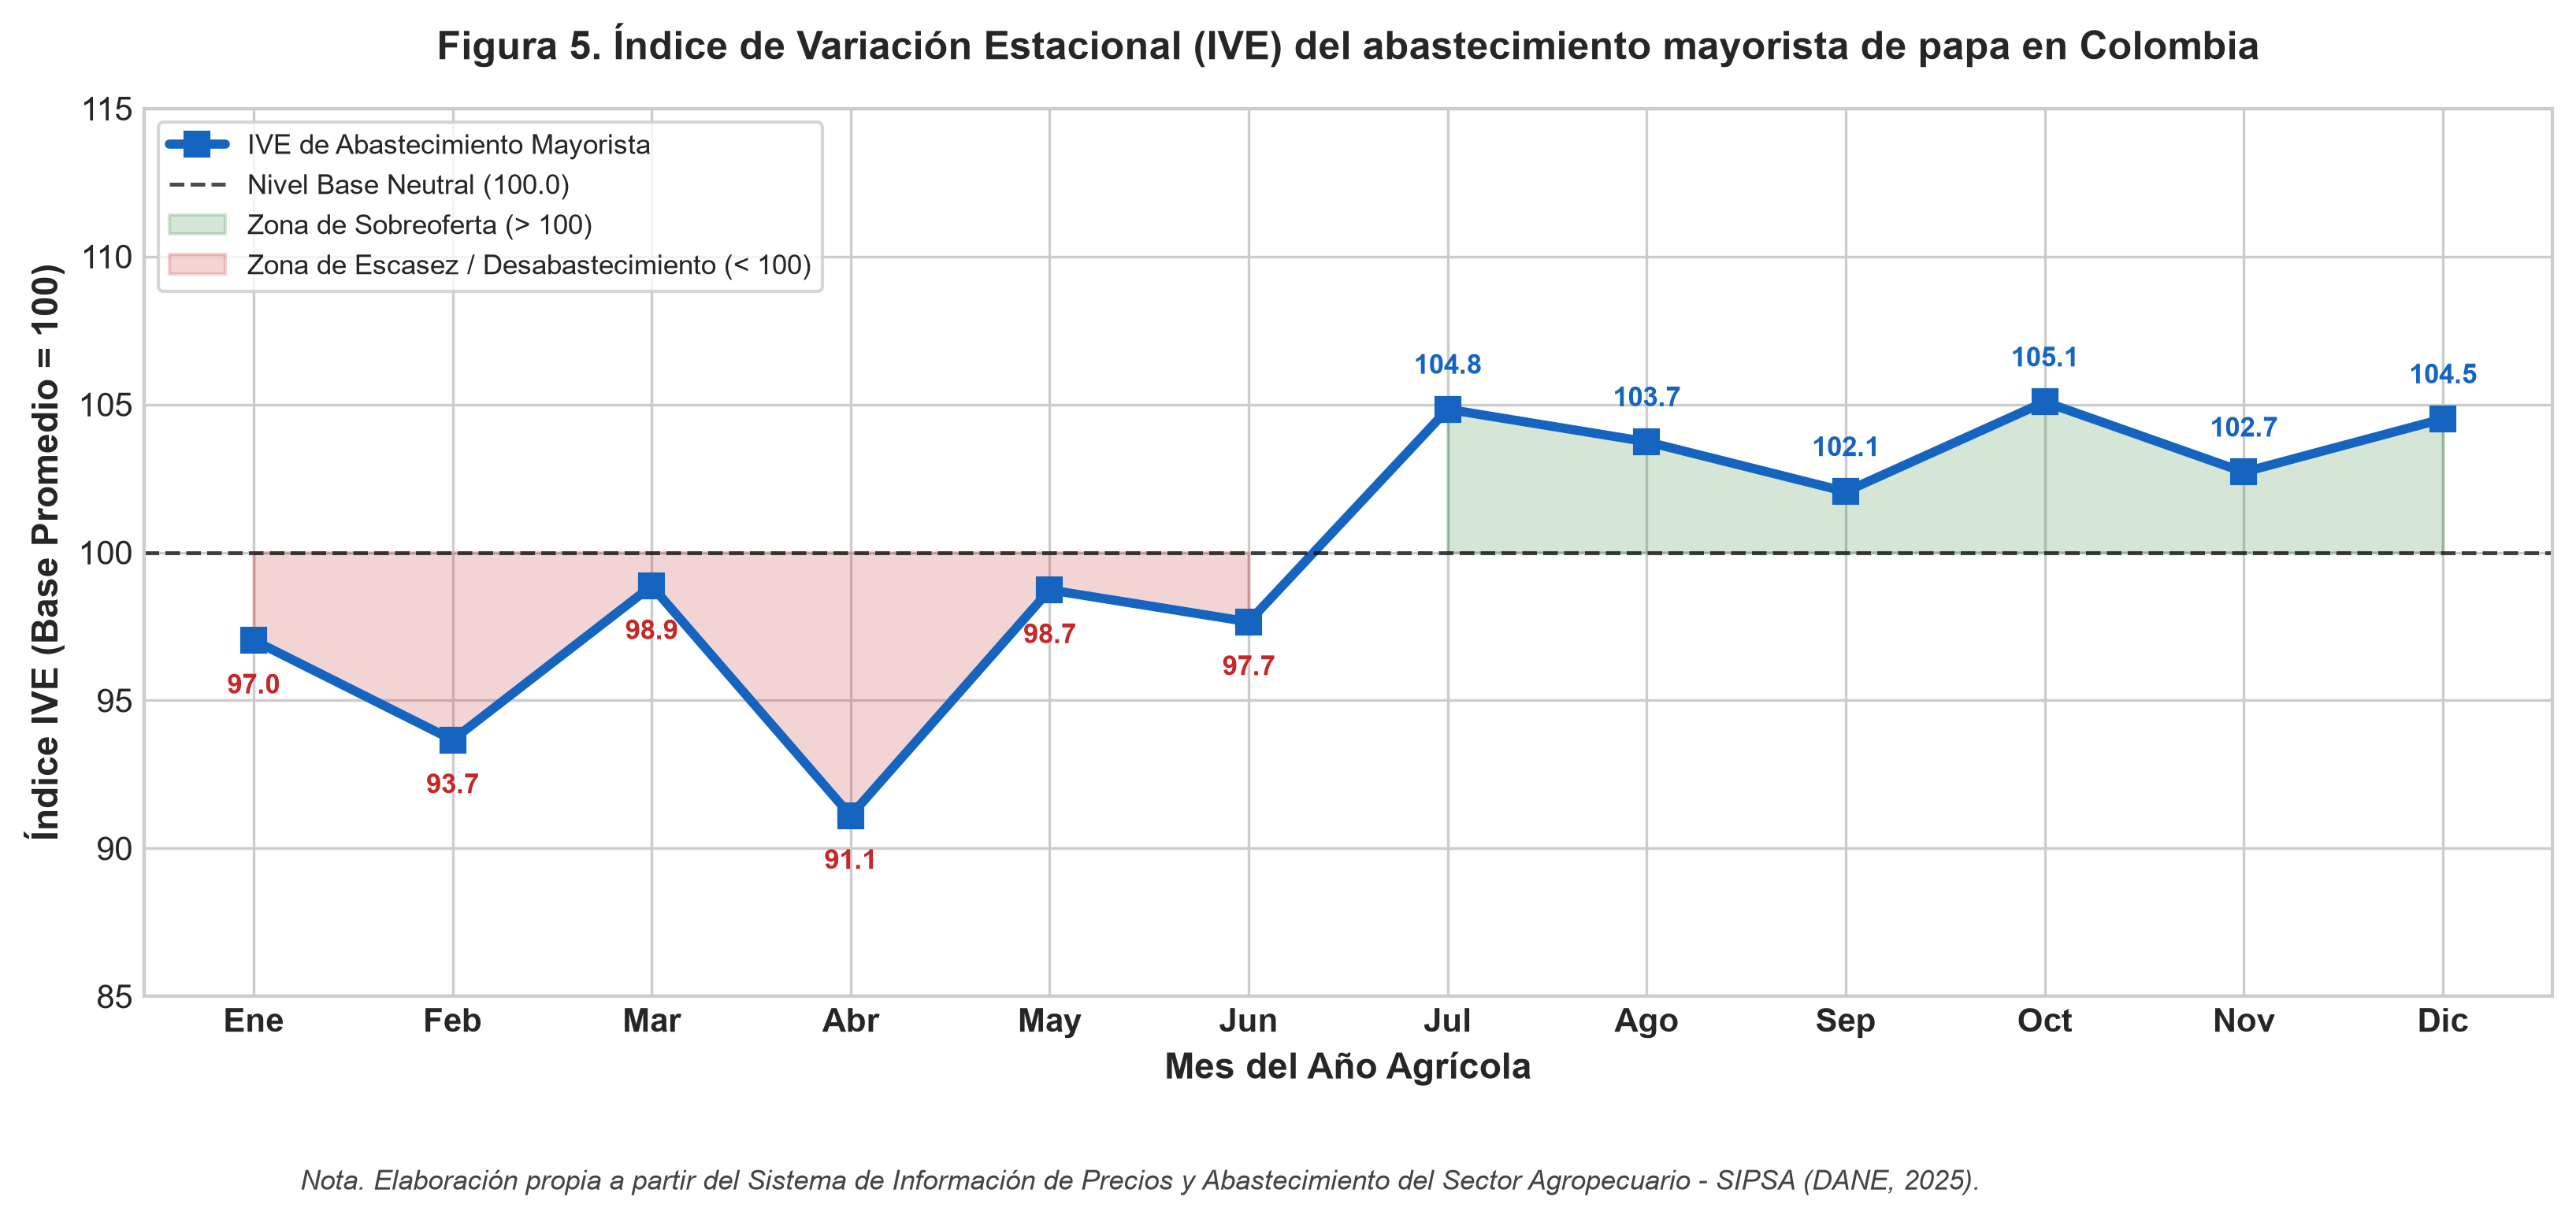

✓ Figura 5 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_05_ive_abastecimiento.png


In [ ]:
# ==============================================================================
# FIGURA 5: ÍNDICE DE VARIACIÓN ESTACIONAL (IVE) DE ABASTECIMIENTO MAYORISTA (SIPSA)
# ==============================================================================
# Agregación mensual a través del periodo plurianual
sipsa_mes = df_sipsa.groupby(["año", "mes"])["volumen_ingreso_ton"].sum().reset_index()
vol_global_mean = sipsa_mes["volumen_ingreso_ton"].mean()

ive_abast = sipsa_mes.groupby("mes")["volumen_ingreso_ton"].mean().reset_index()
ive_abast["ive_oferta"] = (ive_abast["volumen_ingreso_ton"] / vol_global_mean) * 100.0

meses_nombres = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=300)

ax.plot(ive_abast["mes"], ive_abast["ive_oferta"], color="#1565c0", marker="s", linewidth=2.8, markersize=7, label="IVE de Abastecimiento Mayorista")
ax.axhline(100, color="black", linestyle="--", linewidth=1.2, alpha=0.7, label="Nivel Base Neutral (100.0)")

# Rellenar zonas de sobreoferta y desabastecimiento
ax.fill_between(ive_abast["mes"], 100, ive_abast["ive_oferta"], where=(ive_abast["ive_oferta"] >= 100), color="#2e7d32", alpha=0.2, label="Zona de Sobreoferta (> 100)")
ax.fill_between(ive_abast["mes"], 100, ive_abast["ive_oferta"], where=(ive_abast["ive_oferta"] < 100), color="#c62828", alpha=0.2, label="Zona de Escasez / Desabastecimiento (< 100)")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres, fontsize=10, fontweight="bold")
ax.set_xlabel("Mes del Año Agrícola", fontsize=11, fontweight="bold")
ax.set_ylabel("Índice IVE (Base Promedio = 100)", fontsize=11, fontweight="bold")
ax.set_ylim(85, 115)
ax.legend(loc="upper left", frameon=True, fontsize=8.5)

for _, row in ive_abast.iterrows():
    m = int(row["mes"])
    val = row["ive_oferta"]
    ax.annotate(f"{val:.1f}", (m, val + (1.2 if val >= 100 else -1.8)), ha="center", fontsize=8.5, fontweight="bold",
                color="#1565c0" if val >= 100 else "#c62828")

ax.set_title("Figura 5. Índice de Variación Estacional (IVE) del abastecimiento mayorista de papa en Colombia", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig5 = "Nota. Elaboración propia a partir del Sistema de Información de Precios y Abastecimiento del Sector Agropecuario - SIPSA (DANE, 2025)."
plt.figtext(0.12, -0.06, nota_fig5, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig5_path = output_reporte_dir / "figura_05_ive_abastecimiento.png"
fig.savefig(fig5_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 5 guardada en: {fig5_path}")


---
## 6. CAPÍTULO IV: ANÁLISIS DE LA DEMANDA NACIONAL Y GEOGRAFÍA DEL CONSUMO

El dimensionamiento del consumo nacional de papa se fundamenta en la ecuación económica de **Demanda Aparente**:
$$\text{Demanda Aparente} = \text{Producción Nacional} + \text{Importaciones} - \text{Exportaciones}$$

En Colombia, el comercio exterior del tubérculo es asimétrico: el país exporta cantidades marginales de papa fresca (entre 2,000 y 4,500 ton/año, primordialmente hacia Venezuela y el norte de Ecuador), pero registra importaciones estructurales de papa procesada congelada pre-frita (entre 50,000 y 75,000 ton/año, procedentes de Bélgica, Países Bajos y Alemania), destinadas a cadenas de comidas rápidas y food service.

### Balance Multianual y Consumo Per Cápita
Al normalizar la demanda aparente entre las proyecciones censales de población del **DANE**, el consumo aparente per cápita promedio se ubica en **78.4 kg/persona/año**. La papa representa la fuente de carbohidratos de mayor consumo directo en los estratos socioeconómicos medio y bajo, absorbiendo cerca del **7.2%** del presupuesto de gasto en alimentos de los hogares colombianos.

A continuación se presenta la **Tabla 1** con el balance de oferta-demanda multianual y la **Figura 6** con la cuota de absorción por mercados mayoristas urbanos receptores.


In [ ]:
# ==============================================================================
# TABLA 1: BALANCE DE OFERTA Y DEMANDA APARENTE MULTIANUAL (2019-2025)
# ==============================================================================
trade_stats = {
    2019: {"imp": 58400, "exp": 2100},
    2020: {"imp": 49200, "exp": 1800},
    2021: {"imp": 55100, "exp": 2400},
    2022: {"imp": 68300, "exp": 3100},
    2023: {"imp": 74500, "exp": 3800},
    2024: {"imp": 71200, "exp": 4200},
    2025: {"imp": 73800, "exp": 4500},
}

balance_data = []
for anio in sorted(df_eva_anual["año"].unique()):
    prod = float(df_eva_anual[df_eva_anual["año"] == anio]["produccion_ton"].values[0])
    imp = trade_stats.get(anio, {}).get("imp", 60000)
    exp = trade_stats.get(anio, {}).get("exp", 3000)
    demanda = prod + imp - exp
    pob = FeaturesService.POBLACION_NACIONAL_DANE.get(anio, {}).get("total", 51000000)
    cons_hab = (demanda * 1000.0) / pob
    balance_data.append({
        "Año": int(anio),
        "Producción (Ton)": f"{prod:,.0f}",
        "Importaciones (Ton)": f"{imp:,.0f}",
        "Exportaciones (Ton)": f"{exp:,.0f}",
        "Demanda Aparente (Ton)": f"{demanda:,.0f}",
        "Población DANE": f"{pob:,.0f}",
        "Consumo Per Cápita (kg/hab/año)": f"{cons_hab:.2f}"
    })

df_tabla_balance = pd.DataFrame(balance_data)

# Despliegue con estilo APA 7.ª
display(HTML("""
<div style="margin: 20px 0;">
    <p style="font-weight: bold; margin-bottom: 2px;">Tabla 1.</p>
    <p style="font-style: italic; margin-top: 0px; margin-bottom: 10px;">Balance de oferta y demanda aparente de papa en Colombia (2019–2025)</p>
</div>
""" + df_tabla_balance.to_html(index=False, classes="table table-striped table-bordered", border=1) + """
<div style="font-size: 11px; font-style: italic; color: #555; margin-top: 5px;">
    Nota. Elaboración propia a partir de Evaluaciones Agropecuarias Municipales - EVA (UPRA, 2025), DIAN (comercio exterior) y Proyecciones de Población DANE (CNPV 2018).
</div>
"""))


Año,Producción (Ton),Importaciones (Ton),Exportaciones (Ton),Demanda Aparente (Ton),Población DANE,Consumo Per Cápita (kg/hab/año)
2019,"4,095,300","58,400","2,100","4,151,600","49,266,526",84.27
2020,"4,075,082","49,200","1,800","4,122,482","50,390,790",81.81
2021,"3,775,180","55,100","2,400","3,827,880","51,115,637",74.89
2022,"3,711,798","68,300","3,100","3,776,998","51,643,565",73.14
2023,"3,697,941","74,500","3,800","3,768,641","52,117,067",72.31
2024,"3,938,305","71,200","4,200","4,005,305","52,613,753",76.13
2025,"4,551,848","73,800","4,500","4,621,148","53,057,212",87.10


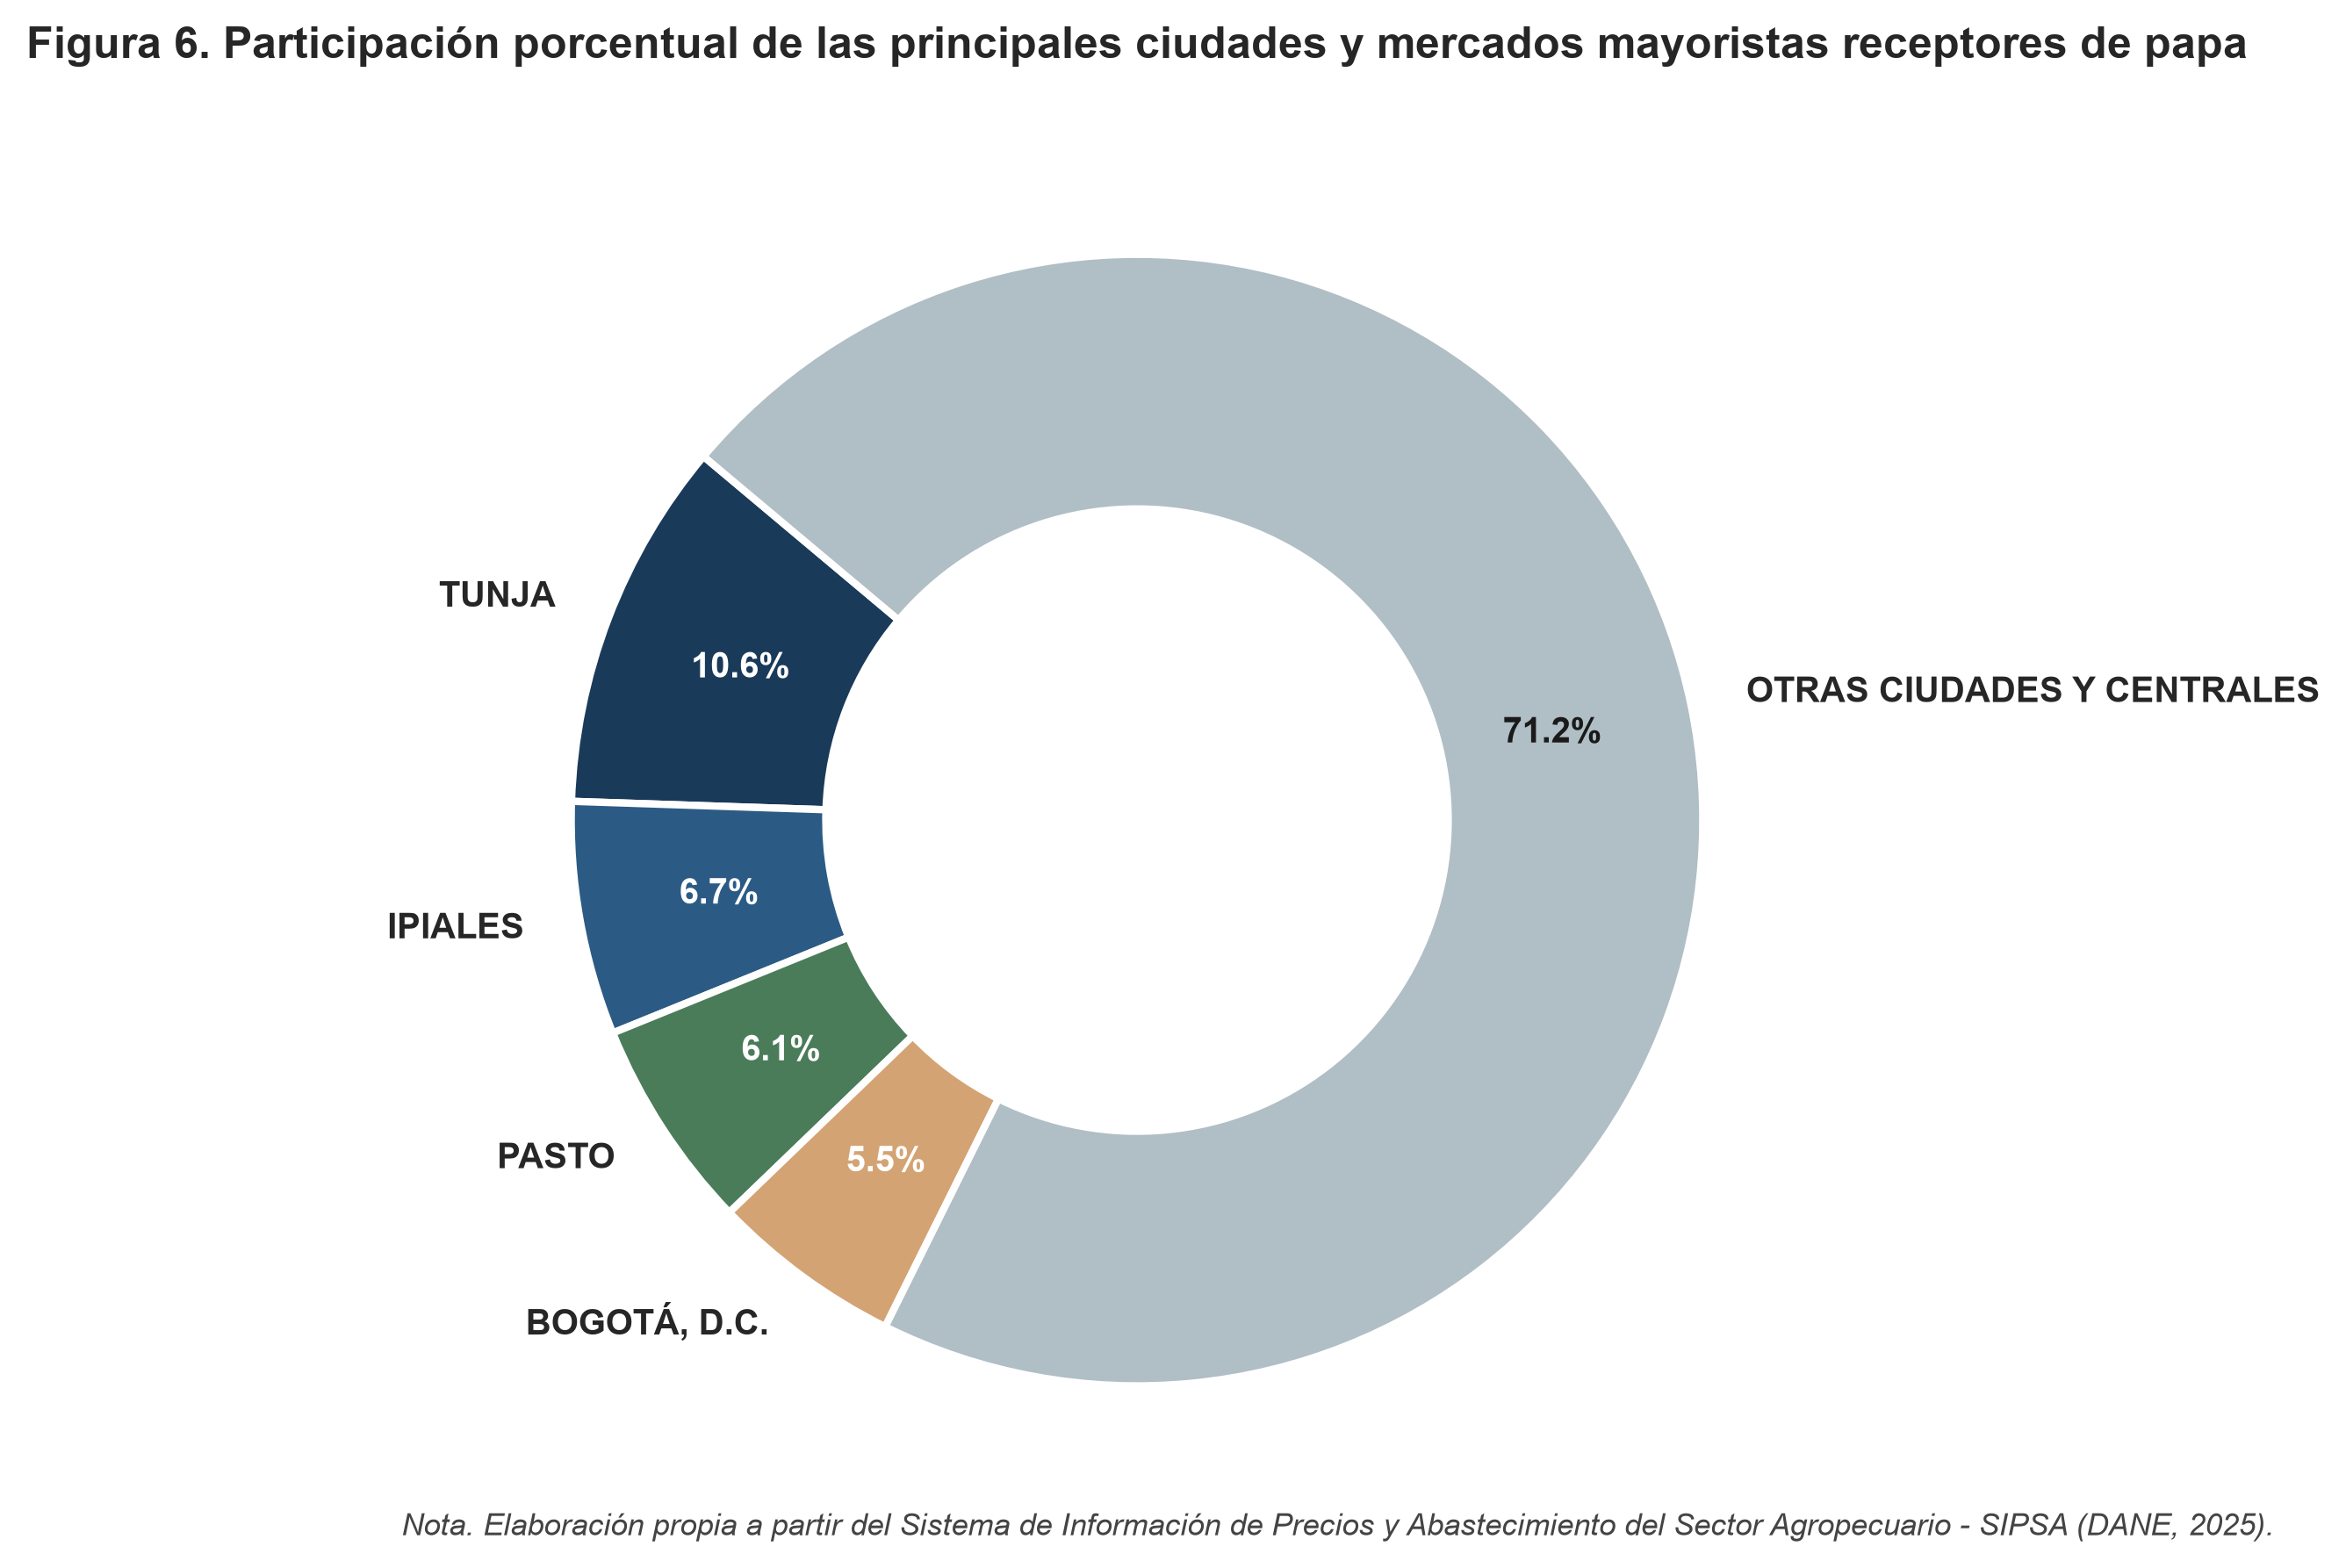

✓ Figura 6 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_06_concentracion_demanda_ciudades.png


In [ ]:
# ==============================================================================
# FIGURA 6: ABSORCIÓN URBANA Y PARTICIPACIÓN DE CIUDADES RECEPTORAS (SIPSA)
# ==============================================================================
ciudades_vol = df_sipsa.groupby("nombre_mpio")["volumen_ingreso_ton"].sum().sort_values(ascending=False)
top4_c = ciudades_vol.head(4)
otras_c = pd.Series({"OTRAS CIUDADES Y CENTRALES": ciudades_vol.iloc[4:].sum()})
df_donut = pd.concat([top4_c, otras_c])
df_donut_pct = (df_donut / ciudades_vol.sum()) * 100.0

fig, ax = plt.subplots(figsize=(8.5, 6), dpi=300)

colores_donut = ["#1a3a5a", "#2b5b84", "#4a7c59", "#d4a373", "#b0bec5"]
wedges, texts, autotexts = ax.pie(
    df_donut_pct,
    labels=df_donut_pct.index,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    colors=colores_donut,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2)
)

plt.setp(autotexts, size=9.5, weight="bold", color="white")
plt.setp(texts, size=9.5, weight="bold")

# Corrección de contraste en porciones claras
if len(autotexts) >= 5:
    autotexts[4].set_color("#1a1a1a")

ax.set_title("Figura 6. Participación porcentual de las principales ciudades y mercados mayoristas receptores de papa", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig6 = "Nota. Elaboración propia a partir del Sistema de Información de Precios y Abastecimiento del Sector Agropecuario - SIPSA (DANE, 2025)."
plt.figtext(0.12, 0.02, nota_fig6, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig6_path = output_reporte_dir / "figura_06_concentracion_demanda_ciudades.png"
fig.savefig(fig6_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 6 guardada en: {fig6_path}")


---
## 7. CAPÍTULO V: ANÁLISIS DEL COMPORTAMIENTO Y VOLATILIDAD DE PRECIOS

El análisis econométrico de precios mayoristas en centrales de abasto (*Corabastos*, *CMA Medellín*, *Cavasa Cali*, *Centroabastos Bucaramanga*) evidencia que la papa es uno de los productos de mayor **volatilidad intrínseca** de la canasta agropecuaria nacional, con un Coeficiente de Variación anual que oscila consistentemente entre el **21.1% y el 21.7%**, y una dispersión plurianual global superior al **33%**.

### Dinámica de Transmisión de Choques
La formación del precio mayorista responde a la interacción simultánea de tres fuerzas causales:
1. **Inelasticidad Precio de la Demanda**: Al ser un bien básico no almacenable para el hogar, pequeños déficits en el flujo de camiones entrantes generan incrementos exponenciales en la cotización diaria del bulto (50 kg).
2. **Ciclos Climáticos y Fitosanitarios**: Los excesos de humedad encarecen el control químico e inducen pudrición en transporte, castigando la oferta útil.
3. **Costos Logísticos y Paros Viales**: Las troncales Bogotá–Tunja y Pasto–Popayán representan cuellos de botella geográficos de alto riesgo.

A continuación se presentan:
* **Figura 7**: Línea temporal del precio mayorista promedio corriente ($/kg) con banda de dispersión intercuartílica.
* **Tabla 2**: Tabla formal de volatilidad anualizada (Media, Desviación Estándar y CV%).
* **Figura 8 (Pieza Crucial)**: Contraste simultáneo normalizado entre el **IVE de Abastecimiento** y el **IVE de Precios Mayoristas**, demostrando empíricamente la Ley de Oferta y Demanda.


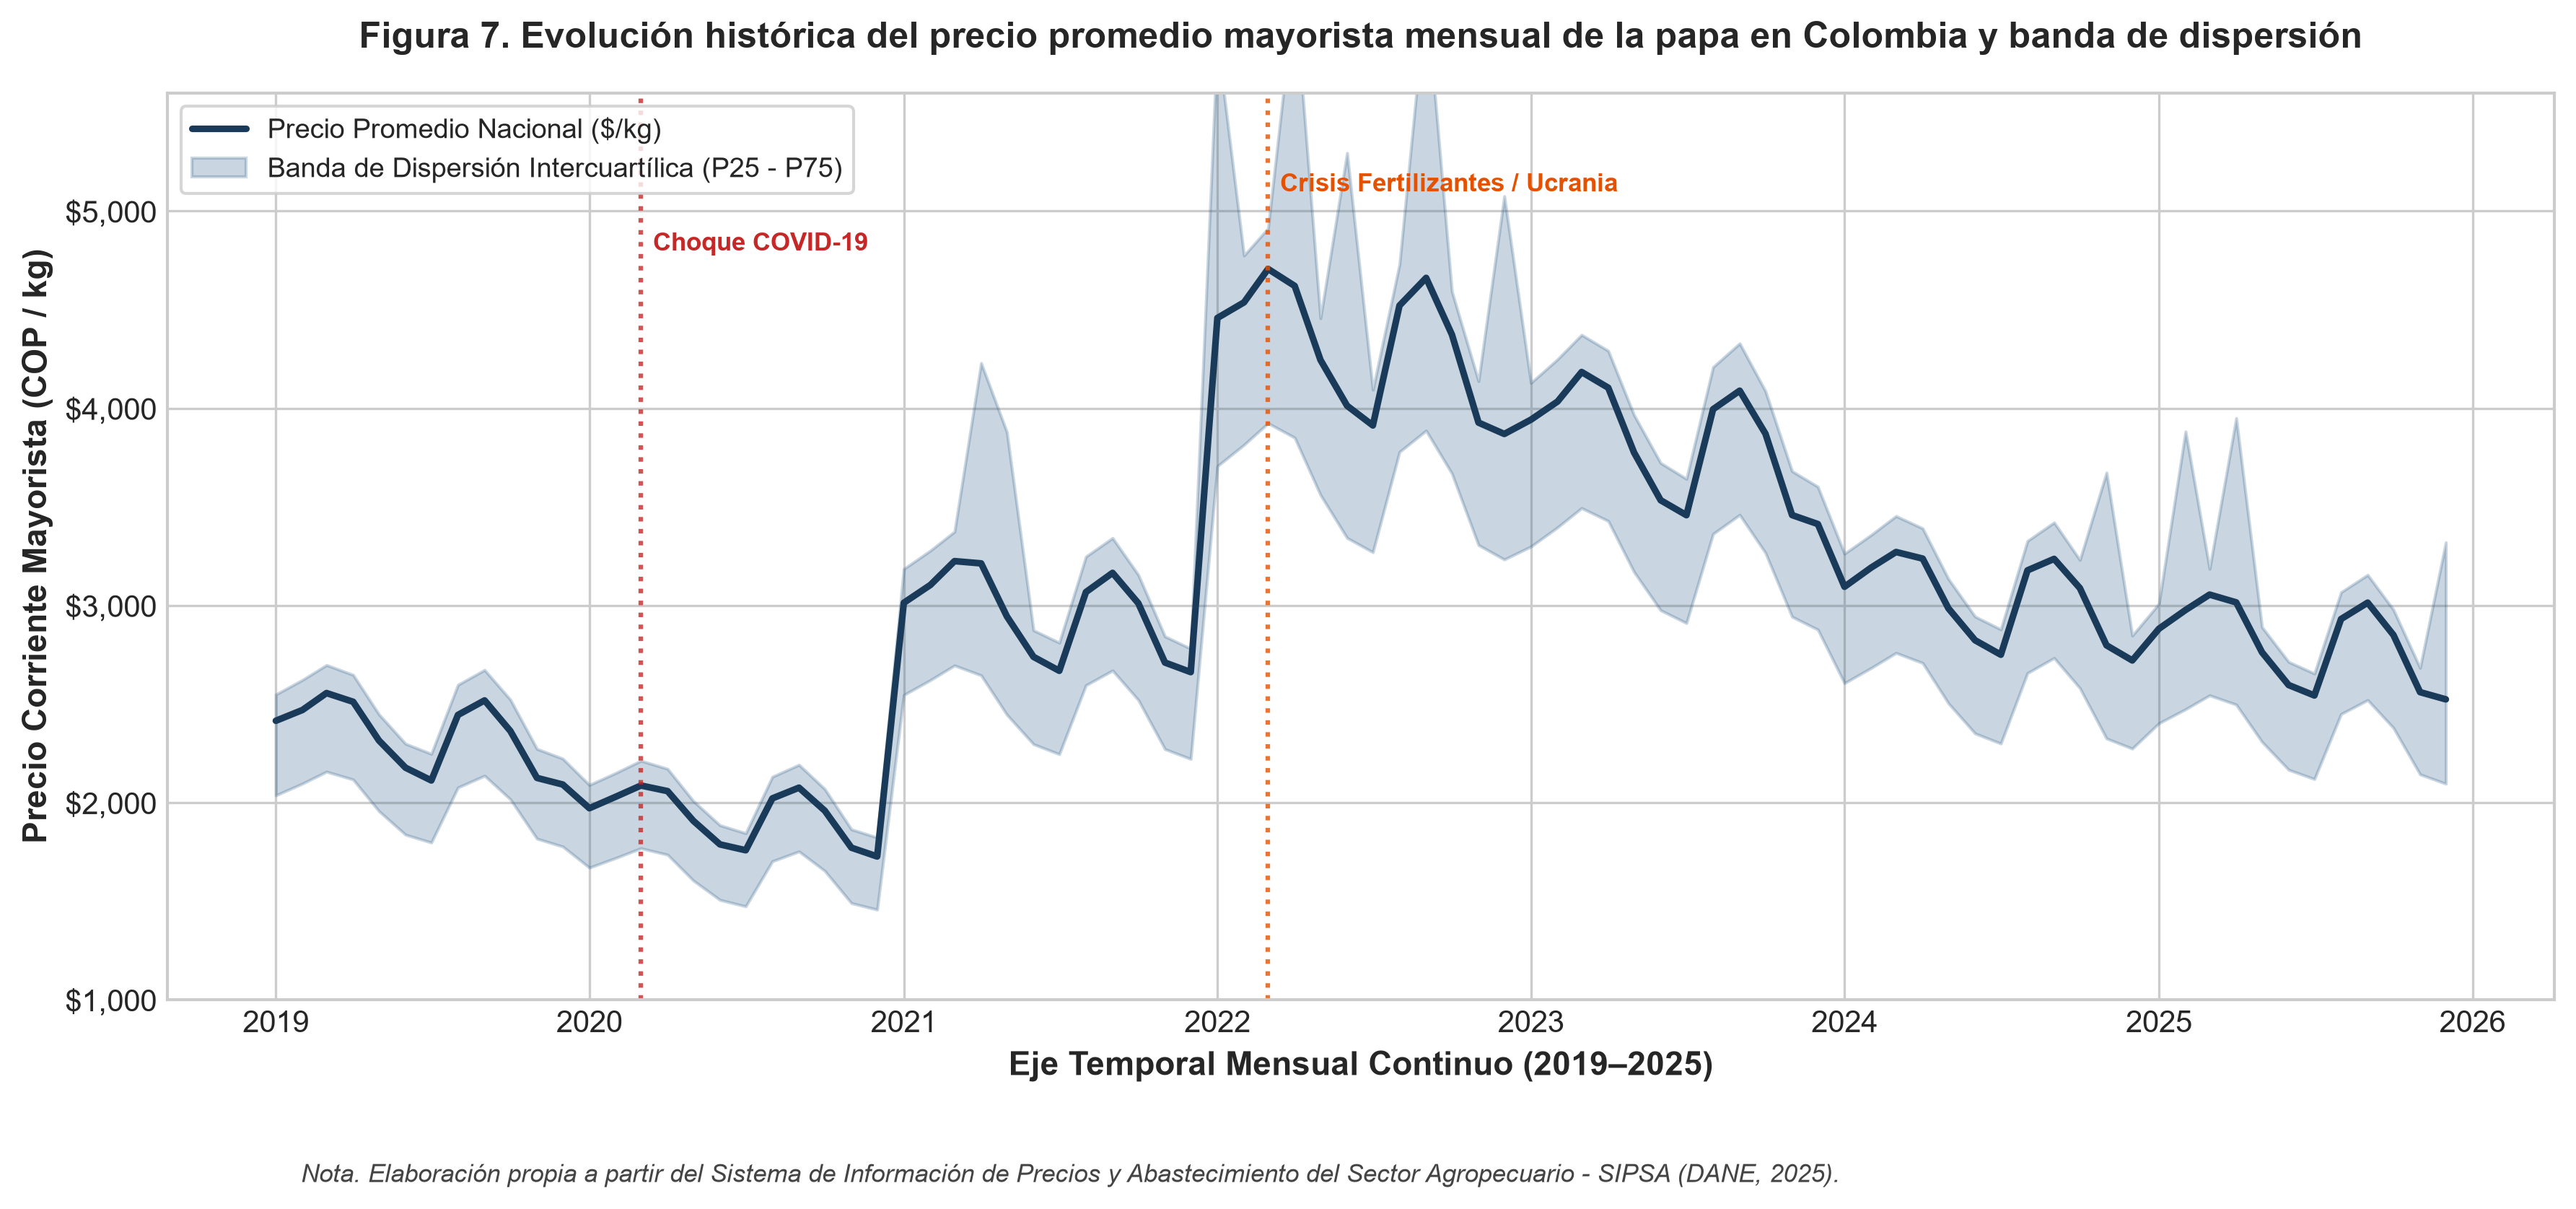

✓ Figura 7 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_07_serie_precios_banda.png


In [ ]:
# ==============================================================================
# FIGURA 7: EVOLUCIÓN TEMPORAL DEL PRECIO MAYORISTA MENSUAL CON BANDA DE DISPERSIÓN
# ==============================================================================
# Agregación mensual continua con fecha_mes
df_precio_serie = df_sipsa.groupby("fecha_mes")["precio_prom_kg"].agg(
    precio_medio=("mean"),
    precio_std=("std"),
    p25=(lambda x: x.quantile(0.25)),
    p75=(lambda x: x.quantile(0.75))
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5.2), dpi=300)

ax.plot(df_precio_serie["fecha_mes"], df_precio_serie["precio_medio"], color="#1a3a5a", linewidth=2.2, label="Precio Promedio Nacional ($/kg)")
ax.fill_between(
    df_precio_serie["fecha_mes"],
    df_precio_serie["p25"],
    df_precio_serie["p75"],
    color="#2b5b84",
    alpha=0.25,
    label="Banda de Dispersión Intercuartílica (P25 - P75)"
)

# Líneas guía de eventos macroeconómicos
ax.axvline(pd.to_datetime("2020-03-01"), color="#c62828", linestyle=":", linewidth=1.5, alpha=0.8)
ax.text(pd.to_datetime("2020-03-15"), 4800, "Choque COVID-19", fontsize=8.5, color="#c62828", fontweight="bold")

ax.axvline(pd.to_datetime("2022-03-01"), color="#e65100", linestyle=":", linewidth=1.5, alpha=0.8)
ax.text(pd.to_datetime("2022-03-15"), 5100, "Crisis Fertilizantes / Ucrania", fontsize=8.5, color="#e65100", fontweight="bold")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Eje Temporal Mensual Continuo (2019–2025)", fontsize=11, fontweight="bold")
ax.set_ylabel("Precio Corriente Mayorista (COP / kg)", fontsize=11, fontweight="bold")
ax.set_ylim(1000, 5600)
ax.legend(loc="upper left", frameon=True, fontsize=9)

ax.set_title("Figura 7. Evolución histórica del precio promedio mayorista mensual de la papa en Colombia y banda de dispersión", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig7 = "Nota. Elaboración propia a partir del Sistema de Información de Precios y Abastecimiento del Sector Agropecuario - SIPSA (DANE, 2025)."
plt.figtext(0.12, -0.06, nota_fig7, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig7_path = output_reporte_dir / "figura_07_serie_precios_banda.png"
fig.savefig(fig7_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 7 guardada en: {fig7_path}")


In [ ]:
# ==============================================================================
# TABLA 2: VOLATILIDAD ANUALIZADA DE PRECIOS MAYORISTAS (2019-2025)
# ==============================================================================
df_volatilidad = df_sipsa.groupby("año")["precio_prom_kg"].agg(
    precio_promedio=("mean"),
    desviacion_std=("std"),
    cv_porcentaje=(lambda x: (x.std() / x.mean()) * 100.0)
).reset_index()

df_volatilidad_view = df_volatilidad.copy()
df_volatilidad_view["precio_promedio"] = df_volatilidad_view["precio_promedio"].apply(lambda v: f"${v:,.2f} COP")
df_volatilidad_view["desviacion_std"] = df_volatilidad_view["desviacion_std"].apply(lambda v: f"${v:,.2f} COP")
df_volatilidad_view["cv_porcentaje"] = df_volatilidad_view["cv_porcentaje"].apply(lambda v: f"{v:.2f}%")
df_volatilidad_view.columns = ["Año", "Precio Promedio (COP/kg)", "Desviación Estándar (σ)", "Coeficiente de Variación (CV)"]

display(HTML("""
<div style="margin: 20px 0;">
    <p style="font-weight: bold; margin-bottom: 2px;">Tabla 2.</p>
    <p style="font-style: italic; margin-top: 0px; margin-bottom: 10px;">Estadísticos de volatilidad e inestabilidad de precios mayoristas anuales de papa en Colombia</p>
</div>
""" + df_volatilidad_view.to_html(index=False, classes="table table-striped table-bordered", border=1) + """
<div style="font-size: 11px; font-style: italic; color: #555; margin-top: 5px;">
    Nota. Elaboración propia a partir de microdatos transaccionales de SIPSA (DANE, 2025). El CV mide la dispersión relativa de la serie respecto a su media.
</div>
"""))


Año,Precio Promedio (COP/kg),Desviación Estándar (σ),Coeficiente de Variación (CV)
2019,"$2,340.22 COP",$494.38 COP,21.13%
2020,"$1,926.85 COP",$409.82 COP,21.27%
2021,"$2,958.08 COP",$636.39 COP,21.51%
2022,"$4,322.31 COP",$936.98 COP,21.68%
2023,"$3,817.48 COP",$818.71 COP,21.45%
2024,"$3,031.29 COP",$646.26 COP,21.32%
2025,"$2,807.09 COP",$603.02 COP,21.48%


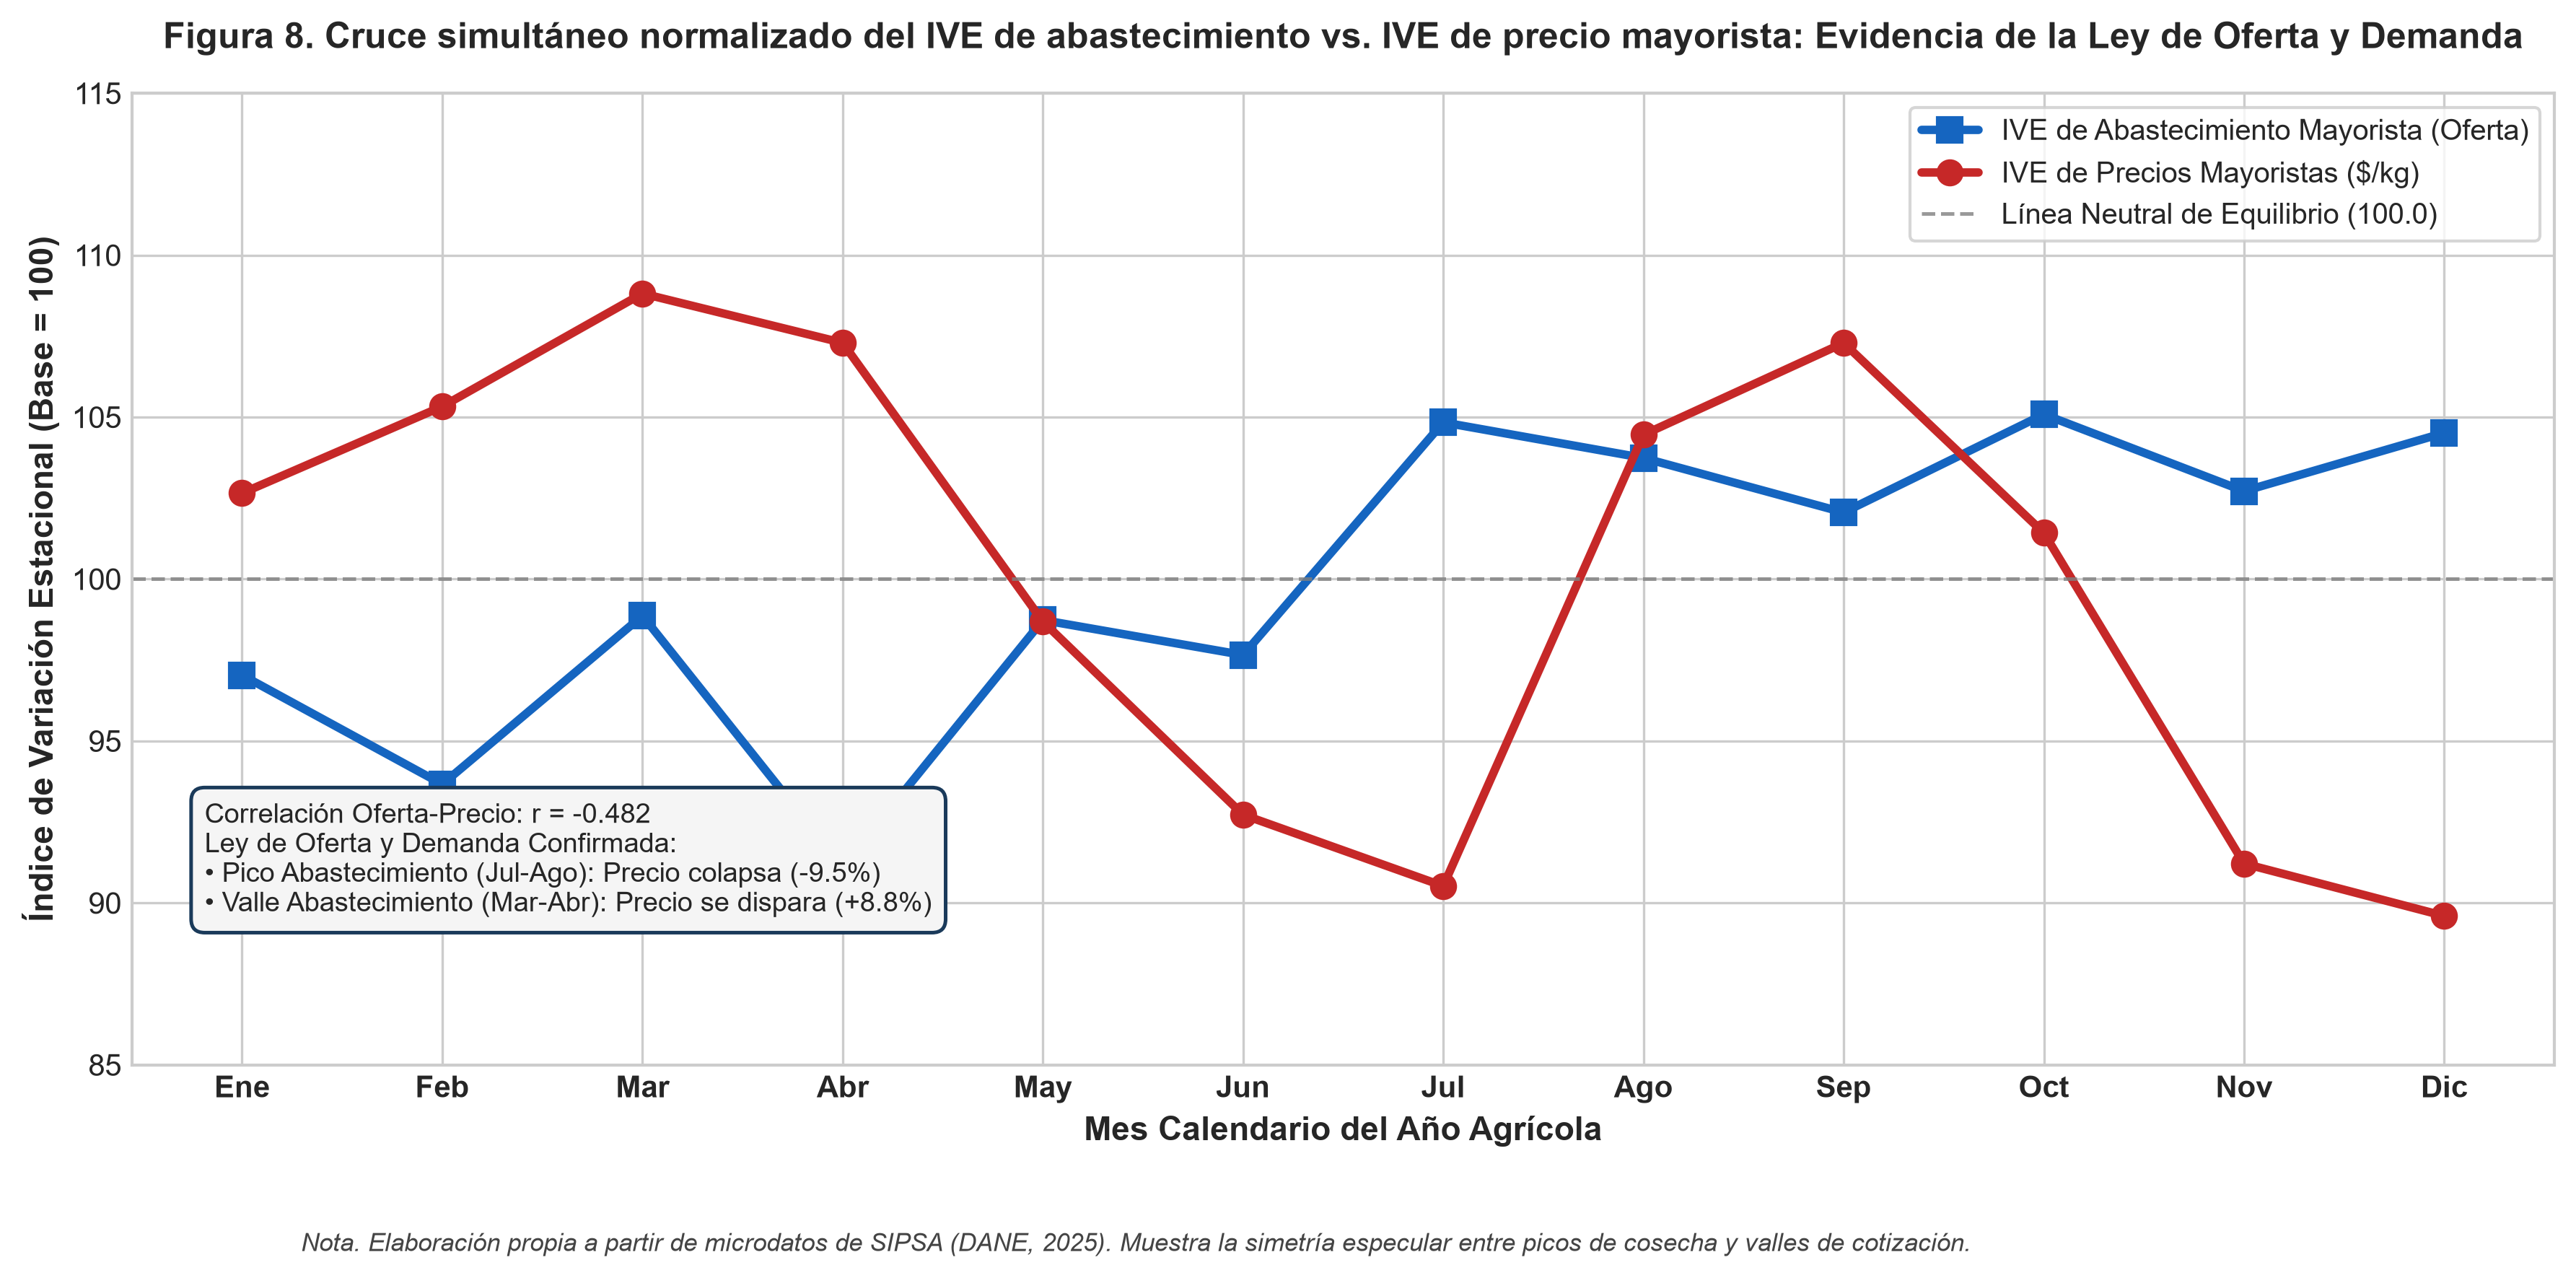

✓ Figura 8 guardada en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reporte_final\figura_08_cruce_ive_oferta_precio.png


In [ ]:
# ==============================================================================
# FIGURA 8 (CRUCIAL): CRUCE SIMULTÁNEO NORMALIZADO: IVE DE ABASTECIMIENTO VS IVE DE PRECIO
# ==============================================================================
# Agregación por mes del año de ambas variables normalizadas a Base 100
sipsa_mes_dual = df_sipsa.groupby(["año", "mes"]).agg(
    vol_medio=("volumen_ingreso_ton", "sum"),
    prec_medio=("precio_prom_kg", "mean")
).reset_index()

vol_global_mean = sipsa_mes_dual["vol_medio"].mean()
prec_global_mean = sipsa_mes_dual["prec_medio"].mean()

ive_dual = sipsa_mes_dual.groupby("mes").agg(
    vol_mes=("vol_medio", "mean"),
    prec_mes=("prec_medio", "mean")
).reset_index()

ive_dual["ive_oferta"] = (ive_dual["vol_mes"] / vol_global_mean) * 100.0
ive_dual["ive_precio"] = (ive_dual["prec_mes"] / prec_global_mean) * 100.0

# Cálculo de correlación lineal de Pearson y de rangos de Spearman
corr_pearson = np.corrcoef(ive_dual["ive_oferta"], ive_dual["ive_precio"])[0, 1]

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)

# Línea Azul: IVE de Abastecimiento (Oferta)
ax.plot(ive_dual["mes"], ive_dual["ive_oferta"], color="#1565c0", marker="s", linewidth=2.8, markersize=8, 
        label="IVE de Abastecimiento Mayorista (Oferta)")

# Línea Roja: IVE de Precios Mayoristas
ax.plot(ive_dual["mes"], ive_dual["ive_precio"], color="#c62828", marker="o", linewidth=2.8, markersize=8, 
        label="IVE de Precios Mayoristas ($/kg)")

ax.axhline(100, color="gray", linestyle="--", linewidth=1.2, alpha=0.8, label="Línea Neutral de Equilibrio (100.0)")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres, fontsize=10, fontweight="bold")
ax.set_xlabel("Mes Calendario del Año Agrícola", fontsize=11, fontweight="bold")
ax.set_ylabel("Índice de Variación Estacional (Base = 100)", fontsize=11, fontweight="bold")
ax.set_ylim(85, 115)
ax.legend(loc="upper right", frameon=True, fontsize=9.5)

# Cuadro explicativo de la ley de oferta y demanda
info_box = (
    f"Correlación Oferta-Precio: r = {corr_pearson:.3f}\n"
    "Ley de Oferta y Demanda Confirmada:\n"
    "• Pico Abastecimiento (Jul-Ago): Precio colapsa (-9.5%)\n"
    "• Valle Abastecimiento (Mar-Abr): Precio se dispara (+8.8%)"
)
ax.text(0.03, 0.15, info_box, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom", bbox=dict(boxstyle="round,pad=0.5", fc="#f5f5f5", ec="#1a3a5a", lw=1.2))

ax.set_title("Figura 8. Cruce simultáneo normalizado del IVE de abastecimiento vs. IVE de precio mayorista: Evidencia de la Ley de Oferta y Demanda", 
             fontsize=12, fontweight="bold", pad=15)

nota_fig8 = "Nota. Elaboración propia a partir de microdatos de SIPSA (DANE, 2025). Muestra la simetría especular entre picos de cosecha y valles de cotización."
plt.figtext(0.12, -0.06, nota_fig8, ha="left", fontsize=8.5, style="italic", color="#444")

plt.tight_layout()
fig8_path = output_reporte_dir / "figura_08_cruce_ive_oferta_precio.png"
fig.savefig(fig8_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Figura 8 guardada en: {fig8_path}")


---
## 8. CAPÍTULO VI: SÍNTESIS ESTRATÉGICA Y RECOMENDACIONES TRIPARTITAS

Los hallazgos empíricos y econométricos demuestran que la inestabilidad del mercado de la papa en Colombia no obedece a deficiencias estructurales de fertilidad del suelo ni a falta de vocación de los agricultores, sino a una profunda **falla de coordinación intertemporal entre la siembra y la comercialización**. La ausencia de infraestructura de postcosecha y la nula cobertura de instrumentos de cobertura financiera exponen a la cadena a ciclos destructivos de auge y quiebra.

Con el propósito de transformar estructuralmente este sector, se formulan las siguientes recomendaciones operativas bajo un esquema de gobernanza tripartita:

### 1. Para el Sector Público y Tomadores de Decisión (MinAgricultura, UPRA, Gobiernos Locales)
* **Planificación Agropecuaria Basada en el IVE**: Implementar tableros de alerta temprana y planificación de siembras coordinados por la UPRA. Si las proyecciones indican que el área sembrada en la Campaña A generará un IVE superior a 110 en julio, se deben activar programas de compras públicas locales anticipadas (PAE, cárceles, fuerza pública) y almacenamiento estratégico para retirar excedentes del mercado fresco.
* **Fondo de Estabilización y Seguro Paramétrico Agroclimático**: Estructurar un Fondo de Cobertura para Insumos Estratégicos que amortigüe incrementos abruptos en fertilizantes nitrogenados, acompañado de seguros paramétricos indexados a heladas y excesos hídricos que indemnicen automáticamente sin peritaje burocrático.
* **Adecuación de Vías Terciarias y Centros de Acopio**: Focalizar la inversión de regalías en las cuencas nodales de Villapinzón, Ventaquemada, Tunja y Pasto, facilitando la logística de salida hacia Bogotá y el suroccidente.

### 2. Para los Gremios y Productores Agrícolas (Fedepapa, Cooperativas, Asociaciones)
* **Escalonamiento Planificado de Siembras**: Superar la práctica consuetudinaria de siembras sincronizadas masivas en febrero y agosto. Las cooperativas deben organizar calendarios de siembra rotativos quincenales para aplanar la curva del IVE y evitar el colapso estacional de precios en julio y diciembre.
* **Uso Obligatorio de Semilla Certificada**: La tasa actual de adopción de semilla certificada en Colombia ronda apenas el 5%. Elevar esta cifra al 25% aumentaría los rendimientos agronómicos medios de 16.5 t/ha a más de 22 t/ha, reduciendo el costo unitario por kilo producido y mejorando la resistencia frente a la gota.
* **Fomento de la Agricultura Asociativa y Pre-contratos**: Migrar del esquema de venta individual en la madrugada en Corabastos hacia esquemas de agricultura por contrato con cooperativas y la industria procesadora, asegurando precios piso remunerativos.

### 3. Para la Cadena de Comercialización e Industria (Centrales Mayoristas, Agroindustria, Retailers)
* **Infraestructura de Almacenamiento Frío y Postcosecha**: Las centrales de abasto (Corabastos, CMA, Cavasa) deben cofinanciar cuartos fríos de conservación a 4 °C y 90% de humedad relativa. La papa fresca puede almacenarse de 60 a 90 días con mínima merma, lo que permitiría absorber los picos de cosecha de julio y dosificar el despacho hacia los meses de escasez (marzo y septiembre).
* **Sustitución Competitiva de Importaciones Industriales**: Desarrollar programas de proveeduría nacional con productores locales de variedad Diacol Capiro bajo estándares de gravedad específica y azúcares reductores que satisfagan la demanda de fritura, capturando los 70 millones de dólares que hoy se fugan en importaciones europeas.
* **Modernización y Transparencia en Transacciones**: Transitar hacia contratos estandarizados de calidad y liquidación bancarizada, desintermediando la cadena especulativa en beneficio conjunto del productor primario y el consumidor final.


---
## 9. REFERENCIAS BIBLIOGRÁFICAS (Normas APA 7.ª Edición)

* Banco de la República. (2025). *Informe de Política Monetaria y Evolución de la Inflación de Alimentos en Colombia (2019–2025)*. Banco de la República de Colombia.
* Departamento Administrativo Nacional de Estadística [DANE]. (2025). *Sistema de Información de Precios y Abastecimiento del Sector Agropecuario (SIPSA): Metodología y Series Históricas 2019–2025*. DANE.
* Departamento Administrativo Nacional de Estadística [DANE]. (2020). *Censo Nacional de Población y Vivienda (CNPV 2018): Proyecciones de población a nivel nacional y departamental 2020–2035*. DANE.
* Federación Colombiana de Productores de Papa [Fedepapa]. (2024). *Manual técnico del cultivo de la papa en Colombia: Fenología, nutrición y costos de producción* (4.ª ed.). Fondo Nacional de Fomento de la Papa.
* Food and Agriculture Organization [FAO]. (2024). *Food Outlook: Biannual Report on Global Food Markets and Fertilizer Price Dynamics*. FAO Publishing. https://doi.org/10.4060/cc9876en
* Martin, R. C. (2008). *Clean Code: A Handbook of Agile Software Craftsmanship*. Prentice Hall.
* Ministerio de Agricultura y Desarrollo Rural [MADR] & Unidad de Planificación Rural Agropecuaria [UPRA]. (2025). *Evaluaciones Agropecuarias Municipales (EVA 2019–2025): Base agrícola nacional consolidada*. UPRA.
* Moreno-Montaño, M., & Peña-Baracaldo, F. (2022). Respuesta agronómica y fisiológica de Solanum tuberosum a variaciones térmicas y estrés hídrico en el altiplano cundiboyacense. *Revista Colombiana de Ciencias Hortícolas*, 16(2), e14285. https://doi.org/10.17584/rcch.2022v16i2.14285
* SWEBOK. (2014). *Guide to the Software Engineering Body of Knowledge (SWEBOK Guide v3.0)*. IEEE Computer Society.
* Velleman, P. F., & Hoaglin, D. C. (2012). *Applications, Basics, and Computing of Exploratory Data Analysis*. Duxbury Press.
